In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import warnings
warnings.filterwarnings('ignore')

df_final_dataset = pd.read_csv("data-analysis/final-ecommerce-dataset.csv")

#Revenue
df_revenue_by_month = pd.read_csv("data-analysis/revenue-by-month.csv")
df_revenue_by_category = pd.read_csv("data-analysis/revenue-by-category.csv")
df_revenue_by_customer_segment = pd.read_csv("data-analysis/revenue-by-customer-segment.csv")
df_revenue_per_state = pd.read_csv("data-analysis/revenue-per-state.csv")

#AOV
df_aov_by_category = pd.read_csv("data-analysis/aov-by-category.csv")
df_aov_by_customer_segment = pd.read_csv("data-analysis/aov-by-customer-segment.csv")
df_aov_by_month = pd.read_csv("data-analysis/aov-by-month.csv")

#Customer
df_customer_type_over_time = pd.read_csv("data-analysis/customer-type-over-time.csv")
df_customer_order_frequency_buckets = pd.read_csv("data-analysis/customer-order-frequency-buckets.csv")

#Category
df_category_growth_over_time = pd.read_csv("data-analysis/category-growth-over-time.csv")
df_retention_category_rate = pd.read_csv("data-analysis/retention-category-rate.csv")

#Seller
df_top_seller_of_review_delivery = pd.read_csv("data-analysis/top-seller-of-review-delivery.csv")

In [2]:
df_final_dataset.head()

,order_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,customer_id,customer_unique_id,customer_city,customer_state,customer_zip_code_prefix,...,product_length_cm,product_height_cm,product_width_cm,total_payment_value,payment_type,payment_installments,avg_review_score,revenue,delivery_days,late_delivery_flag
0,001d8f0e34a38c37f7dba2a37d4eba8b,delivered,2017-05-14 17:19:44+07,2017-05-26 13:14:50+07,2017-05-24 00:00:00+07,d987da9fb4086ab7c2c0f83963cd6722,870a0bdc769f9a7870309036740e79ea,sao paulo,SP,2929,...,43.0,13.0,14.0,53.54,credit_card,2.0,1.0,26.77,11.0,1
1,00018f77f2f0320c557190d7a144bdd3,delivered,2017-04-26 10:53:06+07,2017-05-12 16:04:24+07,2017-05-15 00:00:00+07,f6dd3ec061db4e3987629fe6b26e5cce,eb28e67c4c0b83846050ddfb8a35d051,santa fe do sul,SP,15775,...,50.0,30.0,40.0,259.83,credit_card,3.0,4.0,259.83,16.0,0
2,000229ec398224ef6ca0657da4fc703e,delivered,2018-01-14 14:33:31+07,2018-01-22 13:19:16+07,2018-02-05 00:00:00+07,6489ae5e4333f3693df5ad4372dab6d3,3818d81c6709e39d06b2738a8d3a2474,para de minas,MG,35661,...,33.0,13.0,33.0,216.87,credit_card,5.0,5.0,216.87,7.0,0
3,00048cc3ae777c65dbb7d2a0634bc1ea,delivered,2017-05-15 21:42:34+07,2017-05-22 13:44:35+07,2017-06-06 00:00:00+07,816cbea969fe5b689b39cfc97a506742,85c835d128beae5b4ce8602c491bf385,uberaba,MG,38017,...,24.0,8.0,15.0,34.59,boleto,1.0,4.0,34.59,6.0,0
4,0005a1a1728c9d785b8e2b08b904576c,delivered,2018-03-19 18:40:33+07,2018-03-29 18:17:31+07,2018-03-29 00:00:00+07,16150771dfd4776261284213b89c304e,639d23421f5517f69d0c3d6e6564cf0e,santos,SP,11075,...,30.0,12.0,16.0,157.60,credit_card,3.0,1.0,157.60,9.0,1


In [3]:
df_final_dataset.columns

Index(['order_id', 'order_status', 'order_purchase_timestamp',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_id', 'customer_unique_id', 'customer_city', 'customer_state',
       'customer_zip_code_prefix', 'geolocation_lat', 'geolocation_lng',
       'order_item_id', 'product_id', 'seller_id', 'price', 'freight_value',
       'product_category_name', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm', 'total_payment_value',
       'payment_type', 'payment_installments', 'avg_review_score', 'revenue',
       'delivery_days', 'late_delivery_flag'],
      dtype='object')

In [4]:
df_final_dataset.tail()

,order_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,customer_id,customer_unique_id,customer_city,customer_state,customer_zip_code_prefix,...,product_length_cm,product_height_cm,product_width_cm,total_payment_value,payment_type,payment_installments,avg_review_score,revenue,delivery_days,late_delivery_flag
112096,ec97666defb2e1fade6931649731f776,delivered,2017-07-06 00:17:31+07,2017-07-31 18:34:28+07,2017-07-28 00:00:00+07,4abad51a71113d2de9e00350623a66ec,86b15d7e1a678212f2cf29f2f7a708ec,sao joao de meriti,RJ,25576,...,40.0,14.0,43.0,144.11,credit_card,1.0,4.0,144.11,25.0,1
112097,ec9b762e44b1848fb62eab0de58e8abf,delivered,2018-08-02 14:43:34+07,2018-08-11 20:24:28+07,2018-08-13 00:00:00+07,41712835c53897cb2647acd1022588dd,a7b4c690609bea24107020ae85cc5aed,taboao da serra,SP,6773,...,30.0,3.0,19.0,52.85,boleto,1.0,NaN,52.85,9.0,0
112098,ec9ddd49d01dfcfe7794a593be6400b3,delivered,2018-03-28 11:26:02+07,2018-04-11 22:11:47+07,2018-04-26 00:00:00+07,5439cd634b1b5e988138fc3f9a791e5a,d814663559835dd0158956bb317ac977,sao paulo,SP,4583,...,39.0,11.0,13.0,385.08,boleto,1.0,4.0,128.36,14.0,0
112099,ec9ddd49d01dfcfe7794a593be6400b3,delivered,2018-03-28 11:26:02+07,2018-04-11 22:11:47+07,2018-04-26 00:00:00+07,5439cd634b1b5e988138fc3f9a791e5a,d814663559835dd0158956bb317ac977,sao paulo,SP,4583,...,39.0,11.0,13.0,385.08,boleto,1.0,4.0,128.36,14.0,0
112100,ec9ddd49d01dfcfe7794a593be6400b3,delivered,2018-03-28 11:26:02+07,2018-04-11 22:11:47+07,2018-04-26 00:00:00+07,5439cd634b1b5e988138fc3f9a791e5a,d814663559835dd0158956bb317ac977,sao paulo,SP,4583,...,39.0,11.0,13.0,385.08,boleto,1.0,4.0,128.36,14.0,0


In [5]:
df_final_dataset.isnull().sum()

order_id                            0
order_status                        0
order_purchase_timestamp            0
order_delivered_customer_date    1912
order_estimated_delivery_date       0
customer_id                         0
customer_unique_id                  0
customer_city                       0
customer_state                      0
customer_zip_code_prefix            0
geolocation_lat                   297
geolocation_lng                   297
order_item_id                       0
product_id                          0
seller_id                           0
price                               0
freight_value                       0
product_category_name            1589
product_weight_g                   18
product_length_cm                  18
product_height_cm                  18
product_width_cm                   18
total_payment_value                 3
payment_type                        3
payment_installments                3
avg_review_score                  925
revenue     

In [6]:
df_final_dataset['order_id'].duplicated().sum()

np.int64(13902)

In [7]:
df_final_dataset['customer_unique_id'].duplicated().sum()

np.int64(17118)

In [8]:
df_final_dataset['product_id'].duplicated().sum()

np.int64(79372)

In [9]:
df_final_dataset = df_final_dataset.drop_duplicates(subset=['order_id','product_id','customer_unique_id'])

In [10]:
df_final_dataset.dropna(subset=['order_delivered_customer_date'], inplace=True)

In [11]:
df_final_dataset.isnull().sum()

order_id                            0
order_status                        0
order_purchase_timestamp            0
order_delivered_customer_date       0
order_estimated_delivery_date       0
customer_id                         0
customer_unique_id                  0
customer_city                       0
customer_state                      0
customer_zip_code_prefix            0
geolocation_lat                   273
geolocation_lng                   273
order_item_id                       0
product_id                          0
seller_id                           0
price                               0
freight_value                       0
product_category_name            1401
product_weight_g                   16
product_length_cm                  16
product_height_cm                  16
product_width_cm                   16
total_payment_value                 1
payment_type                        1
payment_installments                1
avg_review_score                  693
revenue     

In [12]:
df_final_dataset.dropna(subset=['total_payment_value', 'payment_type', 'payment_installments'], inplace=True)

In [13]:
df_final_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100187 entries, 0 to 112098
Data columns (total 29 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       100187 non-null  object 
 1   order_status                   100187 non-null  object 
 2   order_purchase_timestamp       100187 non-null  object 
 3   order_delivered_customer_date  100187 non-null  object 
 4   order_estimated_delivery_date  100187 non-null  object 
 5   customer_id                    100187 non-null  object 
 6   customer_unique_id             100187 non-null  object 
 7   customer_city                  100187 non-null  object 
 8   customer_state                 100187 non-null  object 
 9   customer_zip_code_prefix       100187 non-null  int64  
 10  geolocation_lat                99914 non-null   float64
 11  geolocation_lng                99914 non-null   float64
 12  order_item_id                  1001

In [14]:
df_final_dataset['order_delivered_customer_date'] = pd.to_datetime(df_final_dataset['order_delivered_customer_date'])
df_final_dataset['order_estimated_delivery_date'] = pd.to_datetime(df_final_dataset['order_estimated_delivery_date'])
df_final_dataset['order_purchase_timestamp'] = pd.to_datetime(df_final_dataset['order_purchase_timestamp'])

In [15]:
df_final_dataset['product_category_name'].fillna(value=df_final_dataset['product_category_name'].mode()[0], inplace=True)
df_final_dataset['product_weight_g'].fillna(value=df_final_dataset['product_weight_g'].mode()[0], inplace=True)
df_final_dataset['product_length_cm'].fillna(value=df_final_dataset['product_length_cm'].mode()[0], inplace=True)
df_final_dataset['product_height_cm'].fillna(value=df_final_dataset['product_height_cm'].mode()[0], inplace=True)
df_final_dataset['product_width_cm'].fillna(value=df_final_dataset['product_width_cm'].mode()[0], inplace=True)
df_final_dataset['avg_review_score'].fillna(value=df_final_dataset['avg_review_score'].mode()[0], inplace=True)

In [16]:
df_final_dataset.isnull().sum()

order_id                           0
order_status                       0
order_purchase_timestamp           0
order_delivered_customer_date      0
order_estimated_delivery_date      0
customer_id                        0
customer_unique_id                 0
customer_city                      0
customer_state                     0
customer_zip_code_prefix           0
geolocation_lat                  273
geolocation_lng                  273
order_item_id                      0
product_id                         0
seller_id                          0
price                              0
freight_value                      0
product_category_name              0
product_weight_g                   0
product_length_cm                  0
product_height_cm                  0
product_width_cm                   0
total_payment_value                0
payment_type                       0
payment_installments               0
avg_review_score                   0
revenue                            0
d

In [17]:
df_final_dataset.shape

(100187, 29)

In [18]:
df_final_dataset.columns

Index(['order_id', 'order_status', 'order_purchase_timestamp',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_id', 'customer_unique_id', 'customer_city', 'customer_state',
       'customer_zip_code_prefix', 'geolocation_lat', 'geolocation_lng',
       'order_item_id', 'product_id', 'seller_id', 'price', 'freight_value',
       'product_category_name', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm', 'total_payment_value',
       'payment_type', 'payment_installments', 'avg_review_score', 'revenue',
       'delivery_days', 'late_delivery_flag'],
      dtype='object')

In [19]:
df_final_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100187 entries, 0 to 112098
Data columns (total 29 columns):
 #   Column                         Non-Null Count   Dtype                    
---  ------                         --------------   -----                    
 0   order_id                       100187 non-null  object                   
 1   order_status                   100187 non-null  object                   
 2   order_purchase_timestamp       100187 non-null  datetime64[ns, UTC+07:00]
 3   order_delivered_customer_date  100187 non-null  datetime64[ns, UTC+07:00]
 4   order_estimated_delivery_date  100187 non-null  datetime64[ns, UTC+07:00]
 5   customer_id                    100187 non-null  object                   
 6   customer_unique_id             100187 non-null  object                   
 7   customer_city                  100187 non-null  object                   
 8   customer_state                 100187 non-null  object                   
 9   customer_zip_code_pr

In [20]:
corr_df = df_final_dataset.select_dtypes(include=['int64', 'float64'])
corr_matrix = corr_df.corr()

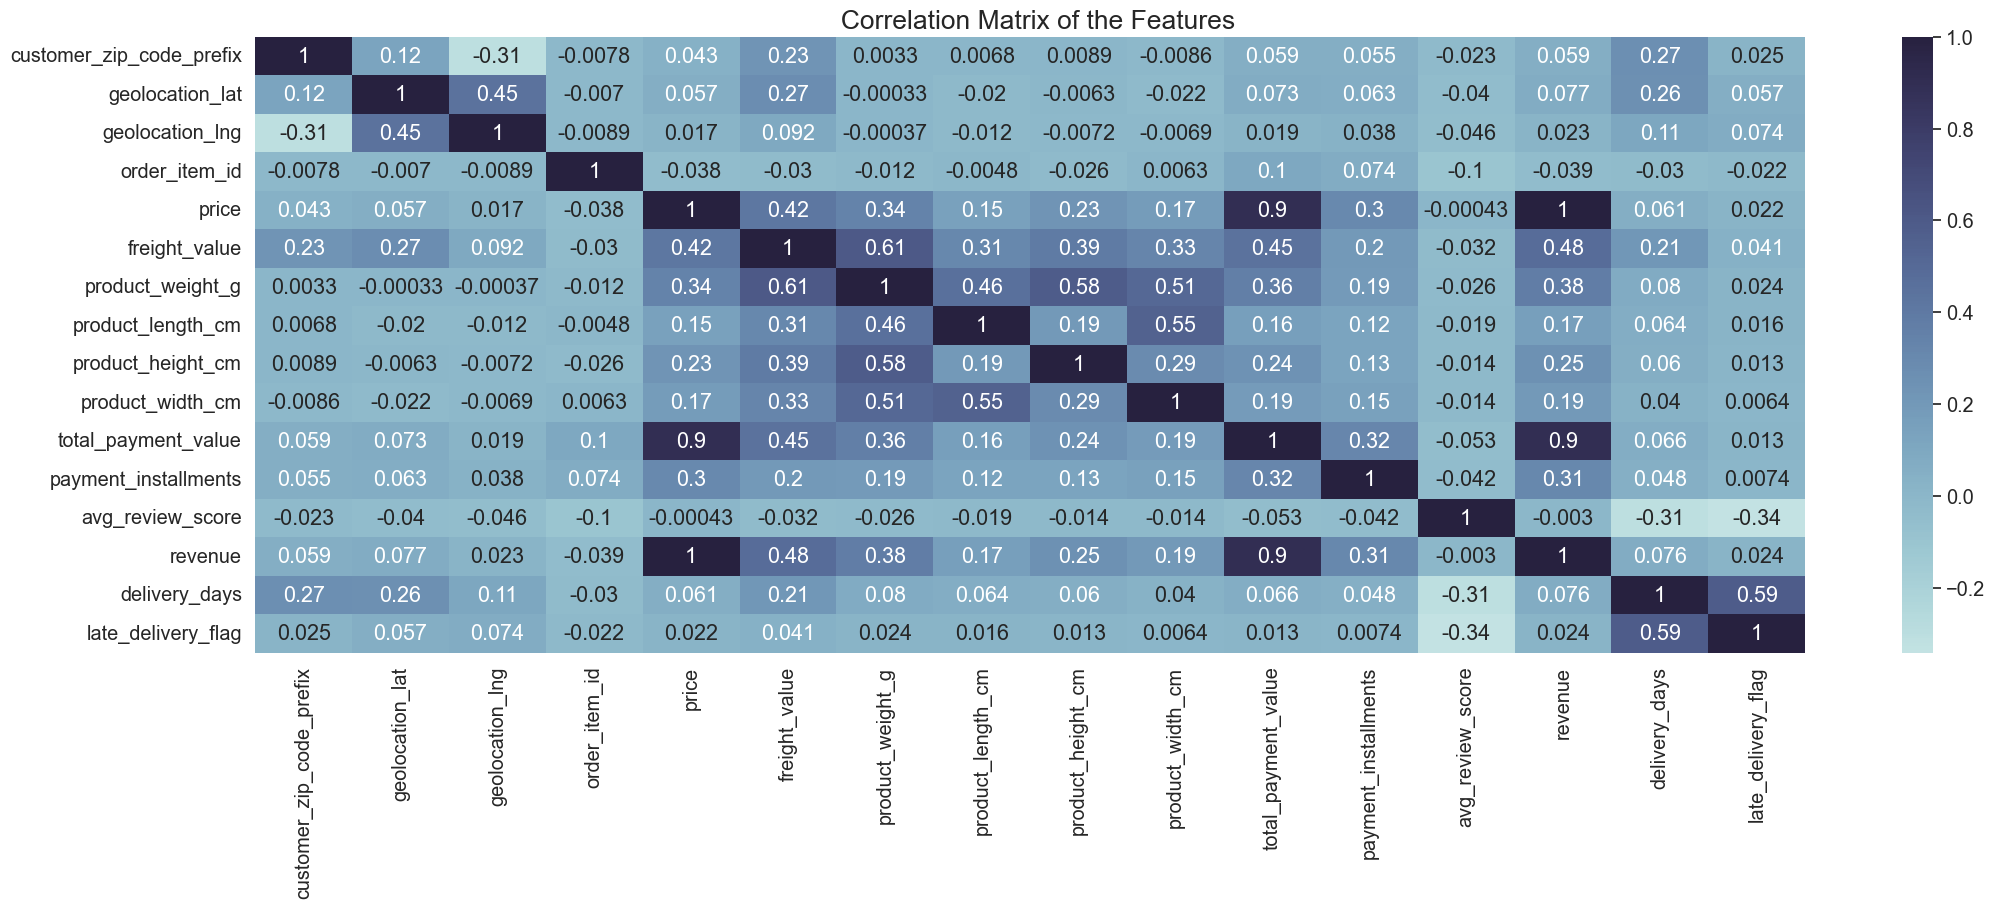

In [21]:
plt.figure(figsize=(25,8))
sns.set(font_scale=1.3)
cmap = sns.color_palette("ch:start=.2,rot=-.3", as_cmap=True)
sns.heatmap(corr_matrix, cmap=cmap,annot=True)
plt.title("  Correlation Matrix of the Features",fontsize=19)
plt.show()

In [22]:
df_revenue_by_month.head()

,month,revenue,quatily_order,mom
0,2016-09-01 00:00:00+07,136.23,1,NaN
1,2016-10-01 00:00:00+07,51657.53,293,37819.35
2,2016-12-01 00:00:00+07,19.62,1,-99.96
3,2017-01-01 00:00:00+07,137006.76,787,698201.53
4,2017-02-01 00:00:00+07,283621.94,1718,107.01


In [23]:
df_revenue_by_month.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   month          24 non-null     object 
 1   revenue        24 non-null     float64
 2   quatily_order  24 non-null     int64  
 3   mom            23 non-null     float64
dtypes: float64(2), int64(1), object(1)
memory usage: 900.0+ bytes


In [24]:
df_revenue_by_month.isnull().sum()

month            0
revenue          0
quatily_order    0
mom              1
dtype: int64

In [25]:
df_revenue_by_month['mom'] = df_revenue_by_month['mom'].fillna(0)

In [26]:
df_revenue_by_month.isnull().sum()

month            0
revenue          0
quatily_order    0
mom              0
dtype: int64

In [27]:
df_revenue_by_month['month'] = pd.to_datetime(df_revenue_by_month['month'])

In [28]:
df_revenue_by_month['year_month'] = (df_revenue_by_month['month'].dt.to_period('M').astype(str)) 

In [29]:
df_revenue_by_month.head()

,month,revenue,quatily_order,mom,year_month
0,2016-09-01 00:00:00+07:00,136.23,1,0.00,2016-09
1,2016-10-01 00:00:00+07:00,51657.53,293,37819.35,2016-10
2,2016-12-01 00:00:00+07:00,19.62,1,-99.96,2016-12
3,2017-01-01 00:00:00+07:00,137006.76,787,698201.53,2017-01
4,2017-02-01 00:00:00+07:00,283621.94,1718,107.01,2017-02


In [30]:
df_revenue_by_month.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype                    
---  ------         --------------  -----                    
 0   month          24 non-null     datetime64[ns, UTC+07:00]
 1   revenue        24 non-null     float64                  
 2   quatily_order  24 non-null     int64                    
 3   mom            24 non-null     float64                  
 4   year_month     24 non-null     object                   
dtypes: datetime64[ns, UTC+07:00](1), float64(2), int64(1), object(1)
memory usage: 1.1+ KB


In [31]:
def bar_plot(x, y, df, colors = sns.color_palette("ch:s=.25,rot=-.25", n_colors=len(df_revenue_by_month)), hue=False, ax=None, value=False, title=''):
    # Preparing variables
    try:
        ncount = sum(df[y])
    except:
        ncount = sum(df[x])

    if hue != False:
        ax = sns.barplot(x=x, y=y, data=df, palette=colors, hue=hue, ax=ax, ci=None)
    else:
        ax = sns.barplot(x=x, y=y, data=df, palette=colors, ax=ax, ci=None)

    # Setting percentage
    for p in ax.patches:
        xp = p.get_bbox().get_points()[:, 0]
        yp = p.get_bbox().get_points()[1, 1]
        if value:
            ax.annotate('{:.2f}k'.format(yp/1000), (xp.mean(), yp), ha='center', va='bottom') # Set the alignment of the text
        else:
            ax.annotate('{:.1f}%'.format(100.*yp/ncount), (xp.mean(), yp), ha='center', va='bottom') # Set the alignment of the text
    plt.tight_layout()
    
def format_spines(ax, right_border=True):
    
    ax.spines['bottom'].set_color('#666666')
    ax.spines['left'].set_color('#666666')
    ax.spines['top'].set_visible(False)
    if right_border:
        ax.spines['right'].set_color('#FFFFFF')
    else:
        ax.spines['right'].set_color('#FFFFFF')
    ax.patch.set_facecolor('#FFFFFF')

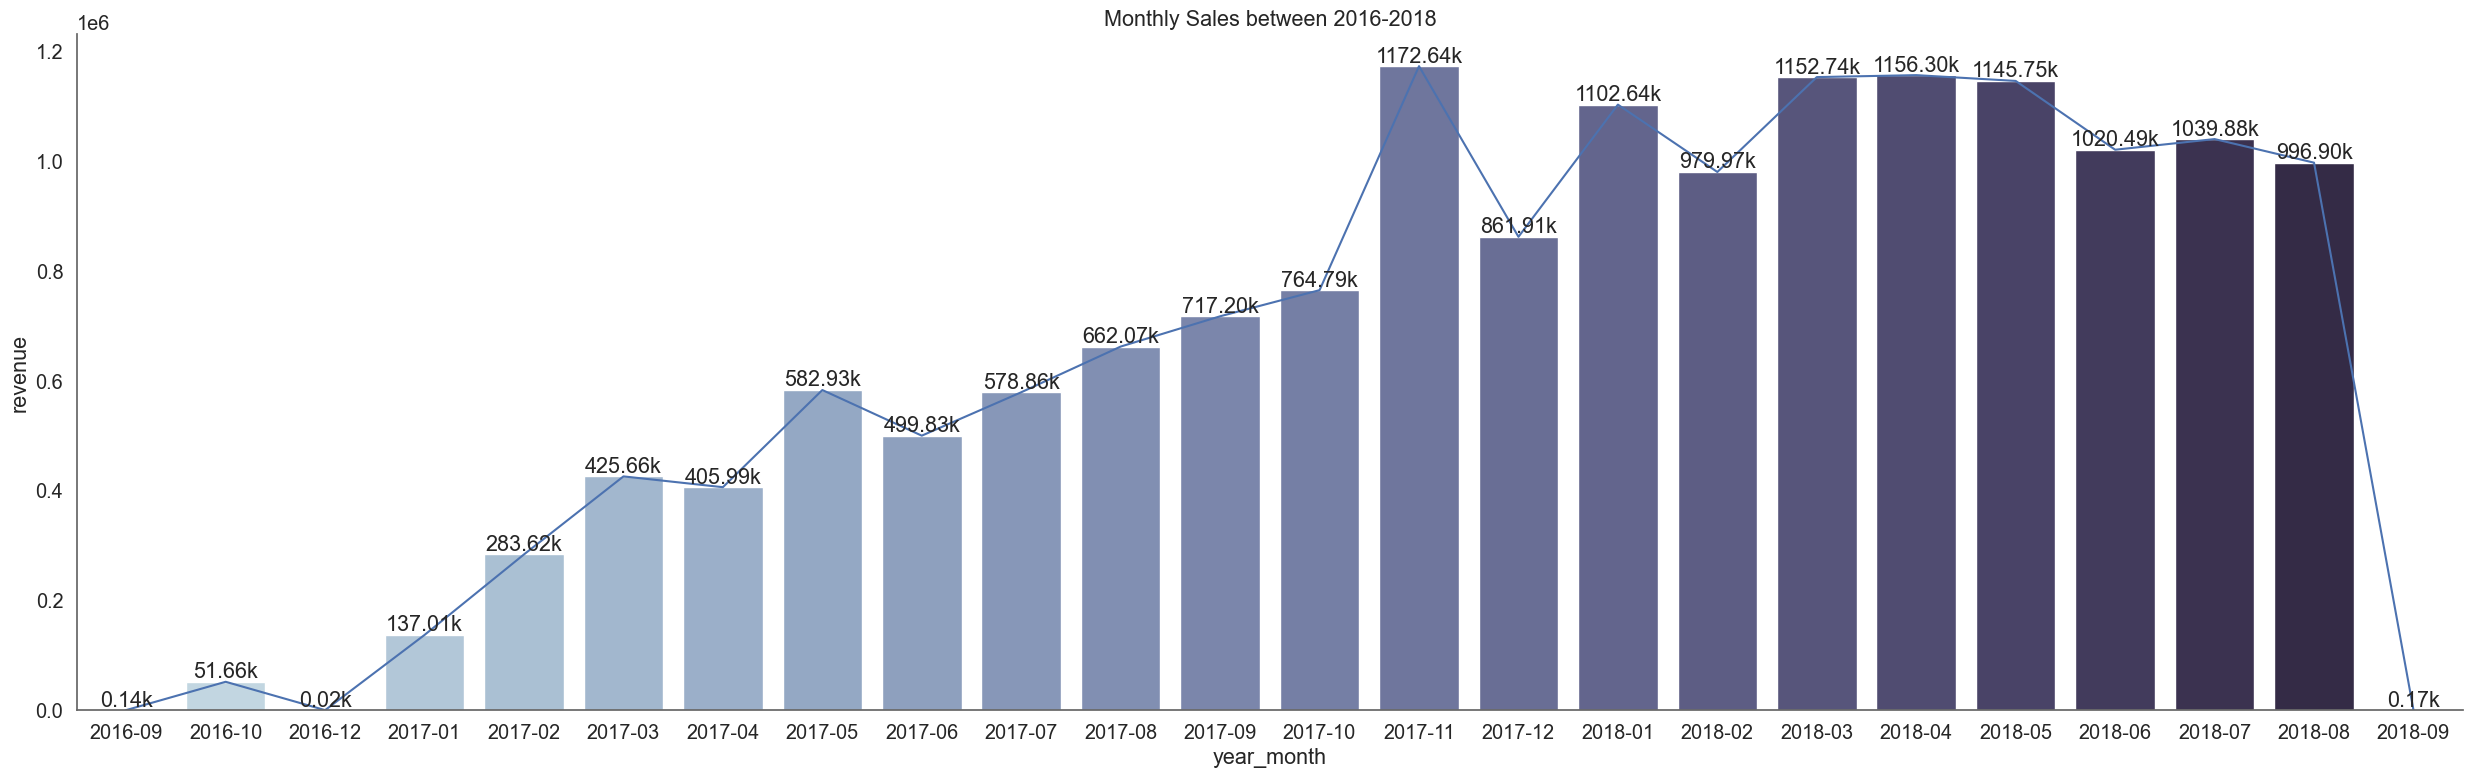

In [32]:
fig, ax = plt.subplots(figsize=(25, 8))
ax = sns.lineplot(x='year_month', y='revenue', data=df_revenue_by_month)
bar_plot(x='year_month', y='revenue', df=df_revenue_by_month, value=True)
format_spines(ax, right_border=False)
ax.set_title('Monthly Sales between 2016-2018');

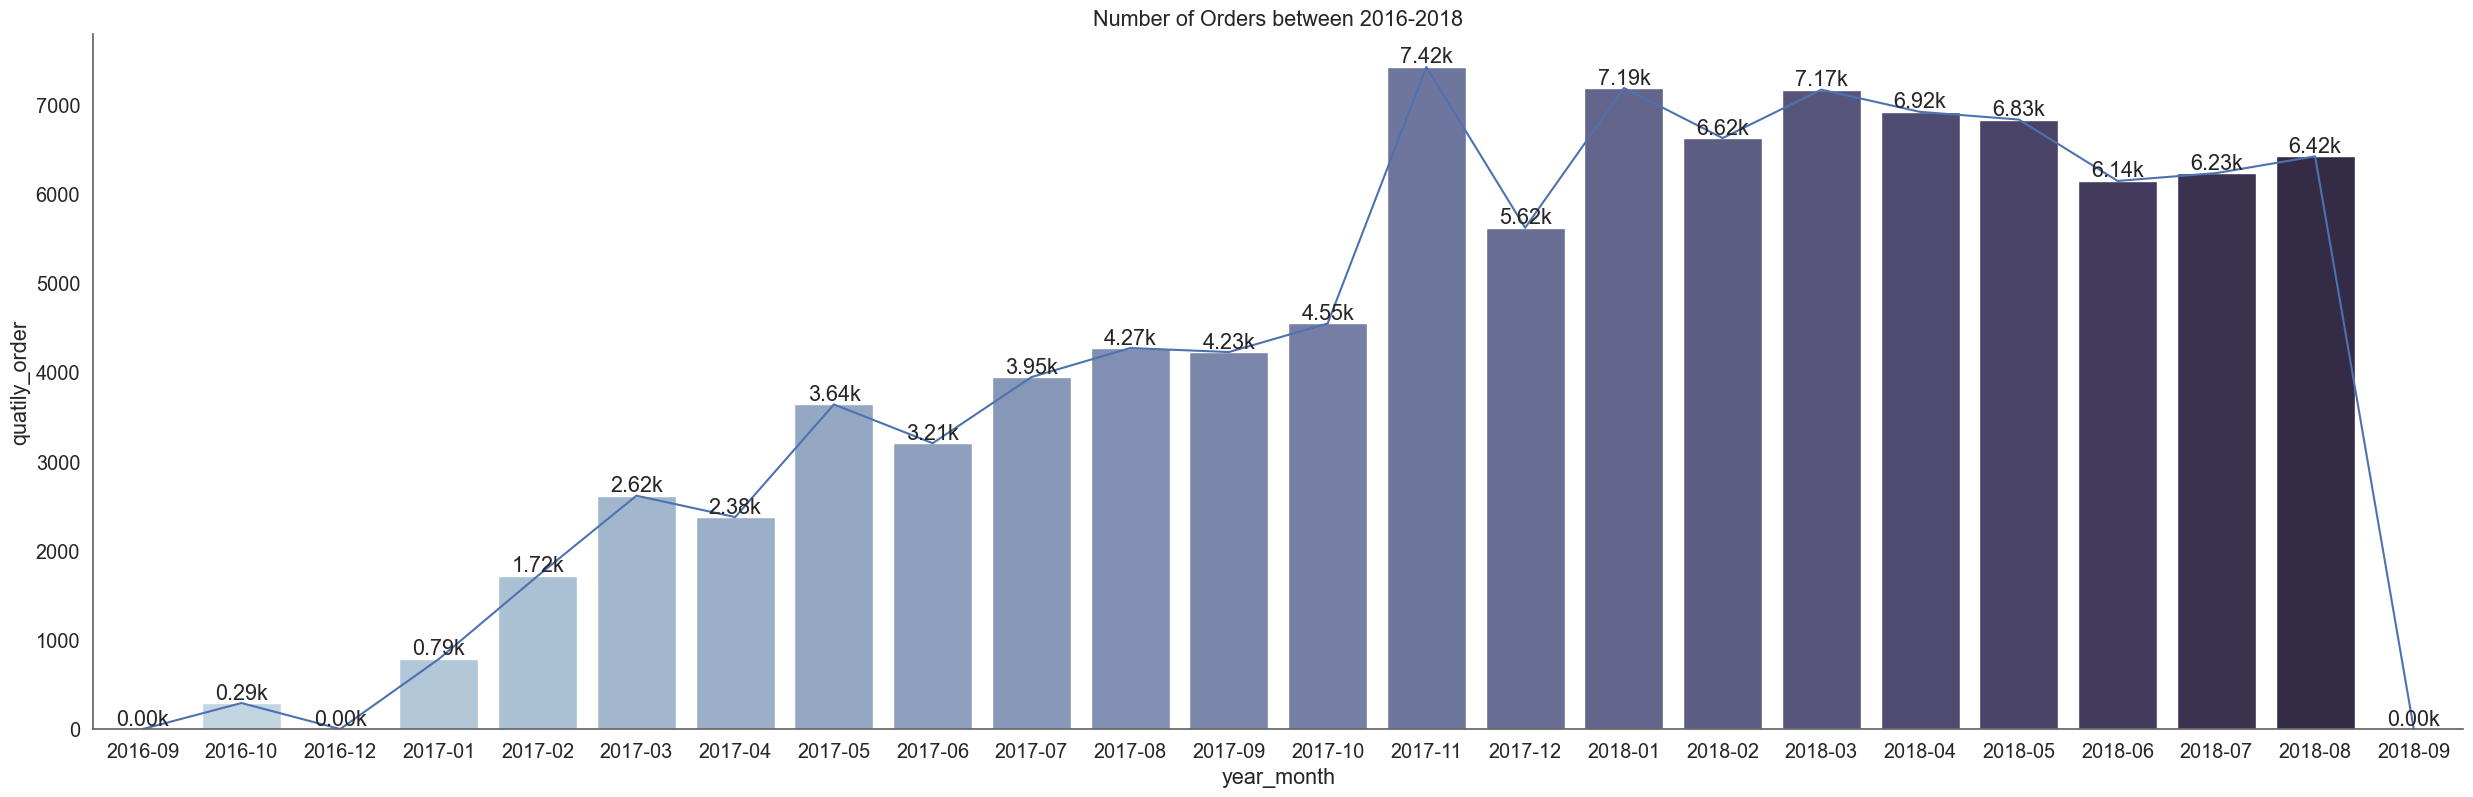

In [33]:
fig, ax = plt.subplots(figsize=(25, 8))
ax = sns.lineplot(x='year_month', y='quatily_order', data=df_revenue_by_month)
bar_plot(x='year_month', y='quatily_order', df=df_revenue_by_month, value=True)
format_spines(ax, right_border=False)
ax.set_title('Number of Orders between 2016-2018');

Insight 

In [34]:
df_aov_by_month.head()

,month,revenue,orders,aov,aov_growth
0,2016-09-01 00:00:00+07,136.23,1,136.23,NaN
1,2016-10-01 00:00:00+07,51657.53,293,176.31,29.42
2,2016-12-01 00:00:00+07,19.62,1,19.62,-88.87
3,2017-01-01 00:00:00+07,137006.76,787,174.09,787.31
4,2017-02-01 00:00:00+07,283621.94,1718,165.09,-5.17


In [35]:
df_aov_by_month.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   month       24 non-null     object 
 1   revenue     24 non-null     float64
 2   orders      24 non-null     int64  
 3   aov         24 non-null     float64
 4   aov_growth  23 non-null     float64
dtypes: float64(3), int64(1), object(1)
memory usage: 1.1+ KB


In [36]:
df_aov_by_month['aov_growth'] = df_aov_by_month['aov_growth'].fillna(0)

In [37]:
df_aov_by_month['month'] = pd.to_datetime(df_aov_by_month['month'])

In [38]:
df_aov_by_month['year_month'] = (df_aov_by_month['month'].dt.to_period('M').astype(str))

In [39]:
df_aov_by_month.head()

,month,revenue,orders,aov,aov_growth,year_month
0,2016-09-01 00:00:00+07:00,136.23,1,136.23,0.00,2016-09
1,2016-10-01 00:00:00+07:00,51657.53,293,176.31,29.42,2016-10
2,2016-12-01 00:00:00+07:00,19.62,1,19.62,-88.87,2016-12
3,2017-01-01 00:00:00+07:00,137006.76,787,174.09,787.31,2017-01
4,2017-02-01 00:00:00+07:00,283621.94,1718,165.09,-5.17,2017-02


In [40]:
df_aov_by_month.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype                    
---  ------      --------------  -----                    
 0   month       24 non-null     datetime64[ns, UTC+07:00]
 1   revenue     24 non-null     float64                  
 2   orders      24 non-null     int64                    
 3   aov         24 non-null     float64                  
 4   aov_growth  24 non-null     float64                  
 5   year_month  24 non-null     object                   
dtypes: datetime64[ns, UTC+07:00](1), float64(3), int64(1), object(1)
memory usage: 1.3+ KB


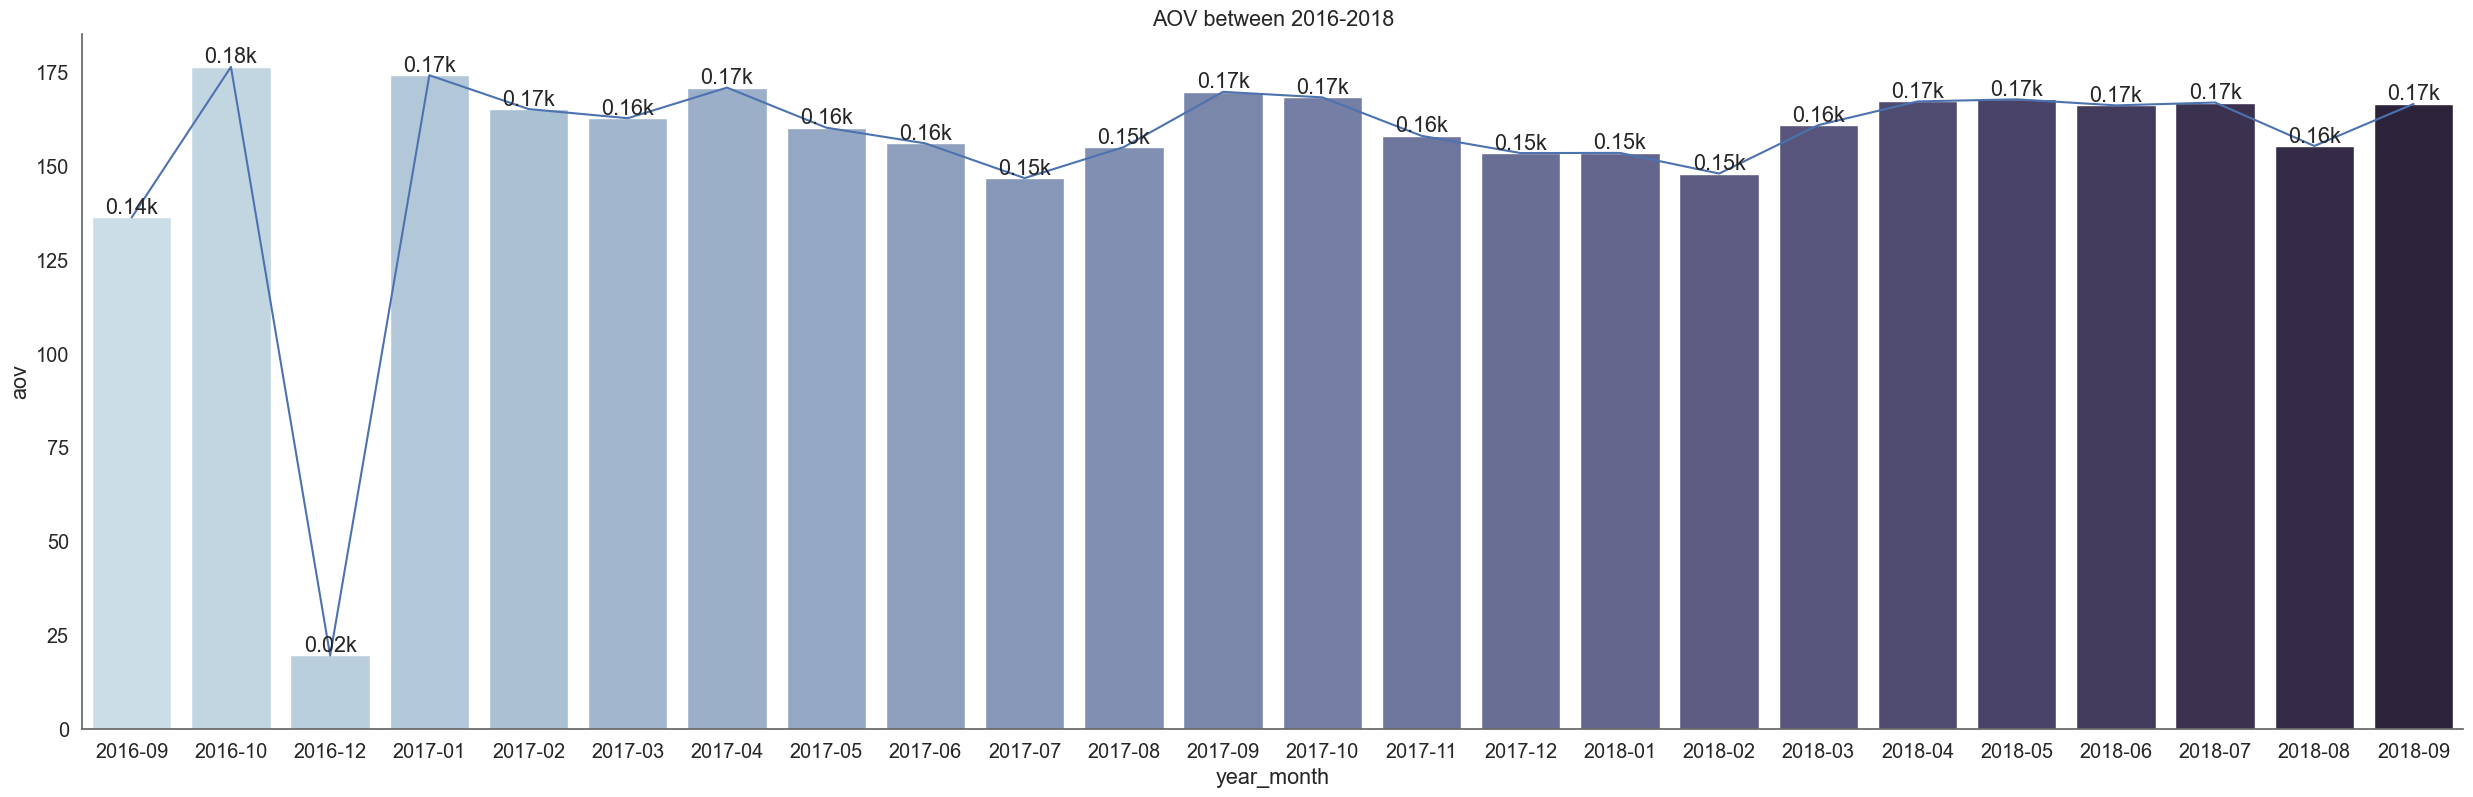

In [41]:
fig, ax = plt.subplots(figsize=(25, 8))
ax = sns.lineplot(x='year_month', y='aov', data=df_aov_by_month)
bar_plot(x='year_month', y='aov', df=df_aov_by_month, value=True)
format_spines(ax, right_border=False)
ax.set_title('AOV between 2016-2018');

Insight

In [42]:
df_category_growth_over_time.head()

,month,category,revenue
0,2016-09-01 00:00:00+07,beleza_saude,143.46
1,2016-09-01 00:00:00+07,moveis_decoracao,136.23
2,2016-10-01 00:00:00+07,alimentos,96.23
3,2016-10-01 00:00:00+07,audio,183.03
4,2016-10-01 00:00:00+07,automotivo,1752.46


In [43]:
df_category_growth_over_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1282 entries, 0 to 1281
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   month     1282 non-null   object 
 1   category  1282 non-null   object 
 2   revenue   1282 non-null   float64
dtypes: float64(1), object(2)
memory usage: 30.2+ KB


In [44]:
df_category_growth_over_time['month'] = pd.to_datetime(df_category_growth_over_time['month'])

In [45]:
df_category_growth_over_time['year_month'] = (df_category_growth_over_time['month'].dt.to_period('M').astype(str))

In [46]:
df_category_growth_over_time.head()

,month,category,revenue,year_month
0,2016-09-01 00:00:00+07:00,beleza_saude,143.46,2016-09
1,2016-09-01 00:00:00+07:00,moveis_decoracao,136.23,2016-09
2,2016-10-01 00:00:00+07:00,alimentos,96.23,2016-10
3,2016-10-01 00:00:00+07:00,audio,183.03,2016-10
4,2016-10-01 00:00:00+07:00,automotivo,1752.46,2016-10


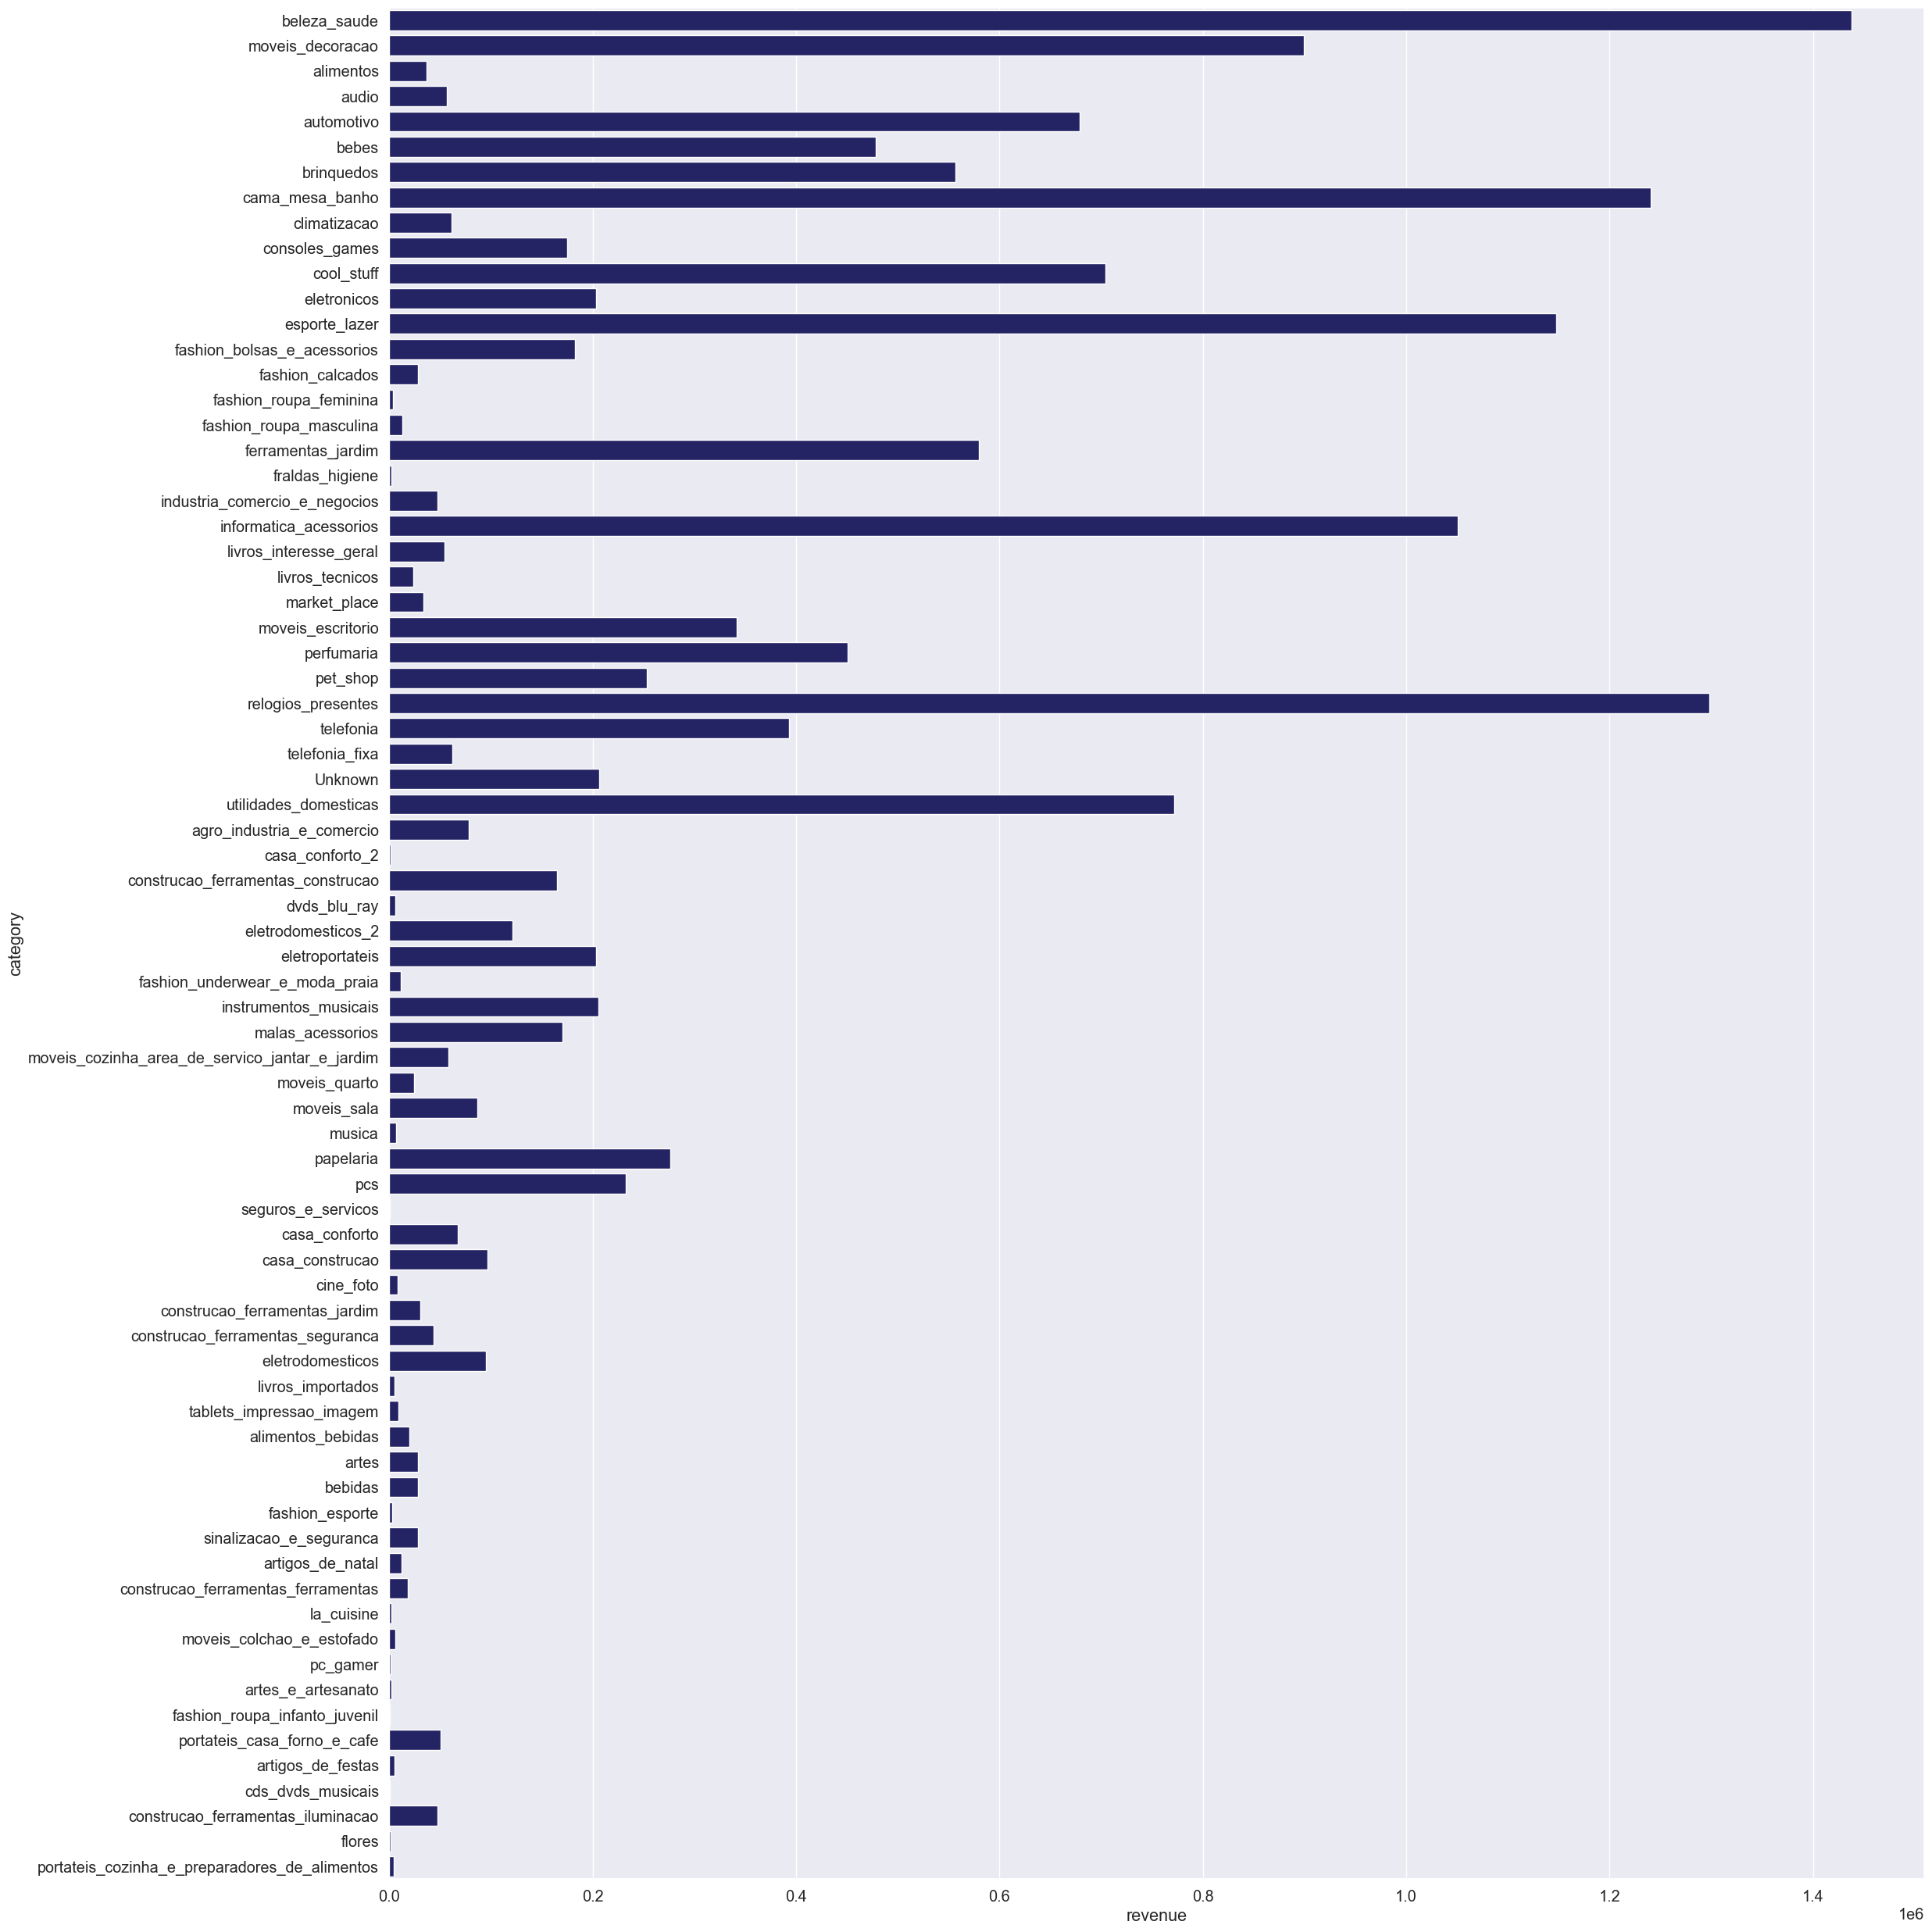

In [47]:
plt.figure(figsize=(25, 25))
sns.barplot(data=df_category_growth_over_time, x='revenue', y='category',estimator=sum, errorbar=None, color='midnightblue')
plt.tight_layout()

In [48]:
df_aov_by_category.head()

,category,revenue,orders,aov
0,pcs,232799.43,181,1286.18
1,portateis_casa_forno_e_cafe,50193.57,75,669.25
2,eletrodomesticos_2,121055.52,231,524.05
3,agro_industria_e_comercio,78374.07,182,430.63
4,instrumentos_musicais,206021.32,620,332.29


In [49]:
df_aov_by_category.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   category  74 non-null     object 
 1   revenue   74 non-null     float64
 2   orders    74 non-null     int64  
 3   aov       74 non-null     float64
dtypes: float64(2), int64(1), object(1)
memory usage: 2.4+ KB


In [50]:
df_category_growth_over_time = df_category_growth_over_time.merge(df_aov_by_category[['category', 'aov', 'orders']], on='category', how='left')

In [51]:
df_category_growth_over_time.head()

,month,category,revenue,year_month,aov,orders
0,2016-09-01 00:00:00+07:00,beleza_saude,143.46,2016-09,163.37,8800
1,2016-09-01 00:00:00+07:00,moveis_decoracao,136.23,2016-09,140.02,6425
2,2016-10-01 00:00:00+07:00,alimentos,96.23,2016-10,81.28,449
3,2016-10-01 00:00:00+07:00,audio,183.03,2016-10,161.52,349
4,2016-10-01 00:00:00+07:00,automotivo,1752.46,2016-10,175.26,3872


In [52]:
df_category_growth_over_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1282 entries, 0 to 1281
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype                    
---  ------      --------------  -----                    
 0   month       1282 non-null   datetime64[ns, UTC+07:00]
 1   category    1282 non-null   object                   
 2   revenue     1282 non-null   float64                  
 3   year_month  1282 non-null   object                   
 4   aov         1282 non-null   float64                  
 5   orders      1282 non-null   int64                    
dtypes: datetime64[ns, UTC+07:00](1), float64(2), int64(1), object(2)
memory usage: 60.2+ KB


In [83]:
# =====================================================
# 1. AGGREGATE TOTAL REVENUE BY CATEGORY
# =====================================================

df_abc = (
    df_category_growth_over_time
    .groupby('category')
    .agg(
        revenue=('revenue', 'sum')
    )
    .reset_index()
)

# =====================================================
# 2. SORT DESCENDING
# =====================================================

df_abc = df_abc.sort_values(
    by='revenue',
    ascending=False
).reset_index(drop=True)

# =====================================================
# 3. CALCULATE REVENUE SHARE
# =====================================================

total_revenue = df_abc['revenue'].sum()

df_abc['revenue_share'] = (
    df_abc['revenue'] / total_revenue
)

# cumulative revenue share
df_abc['cumulative_share'] = (
    df_abc['revenue_share']
    .cumsum()
)

# =====================================================
# 4. CREATE ABC CLUSTER
# =====================================================

conditions = [
    (df_abc['cumulative_share'] > 0.95),

    (
        (df_abc['cumulative_share'] > 0.80) &
        (df_abc['cumulative_share'] <= 0.95)
    ),
    (df_abc['cumulative_share'] <= 0.80)   
]

labels = ['A', 'B', 'C']

df_abc['cluster'] = np.select(
    conditions,
    labels,
    default='C'
)

# =====================================================
# 5. CHECK RESULT
# =====================================================

df_abc.head()

,category,revenue,revenue_share,cumulative_share,cluster
0,beleza_saude,1437665.78,0.091364,0.091364,C
1,relogios_presentes,1298292.47,0.082507,0.173871,C
2,cama_mesa_banho,1240386.13,0.078827,0.252699,C
3,esporte_lazer,1147244.63,0.072908,0.325606,C
4,informatica_acessorios,1050941.58,0.066788,0.392394,C


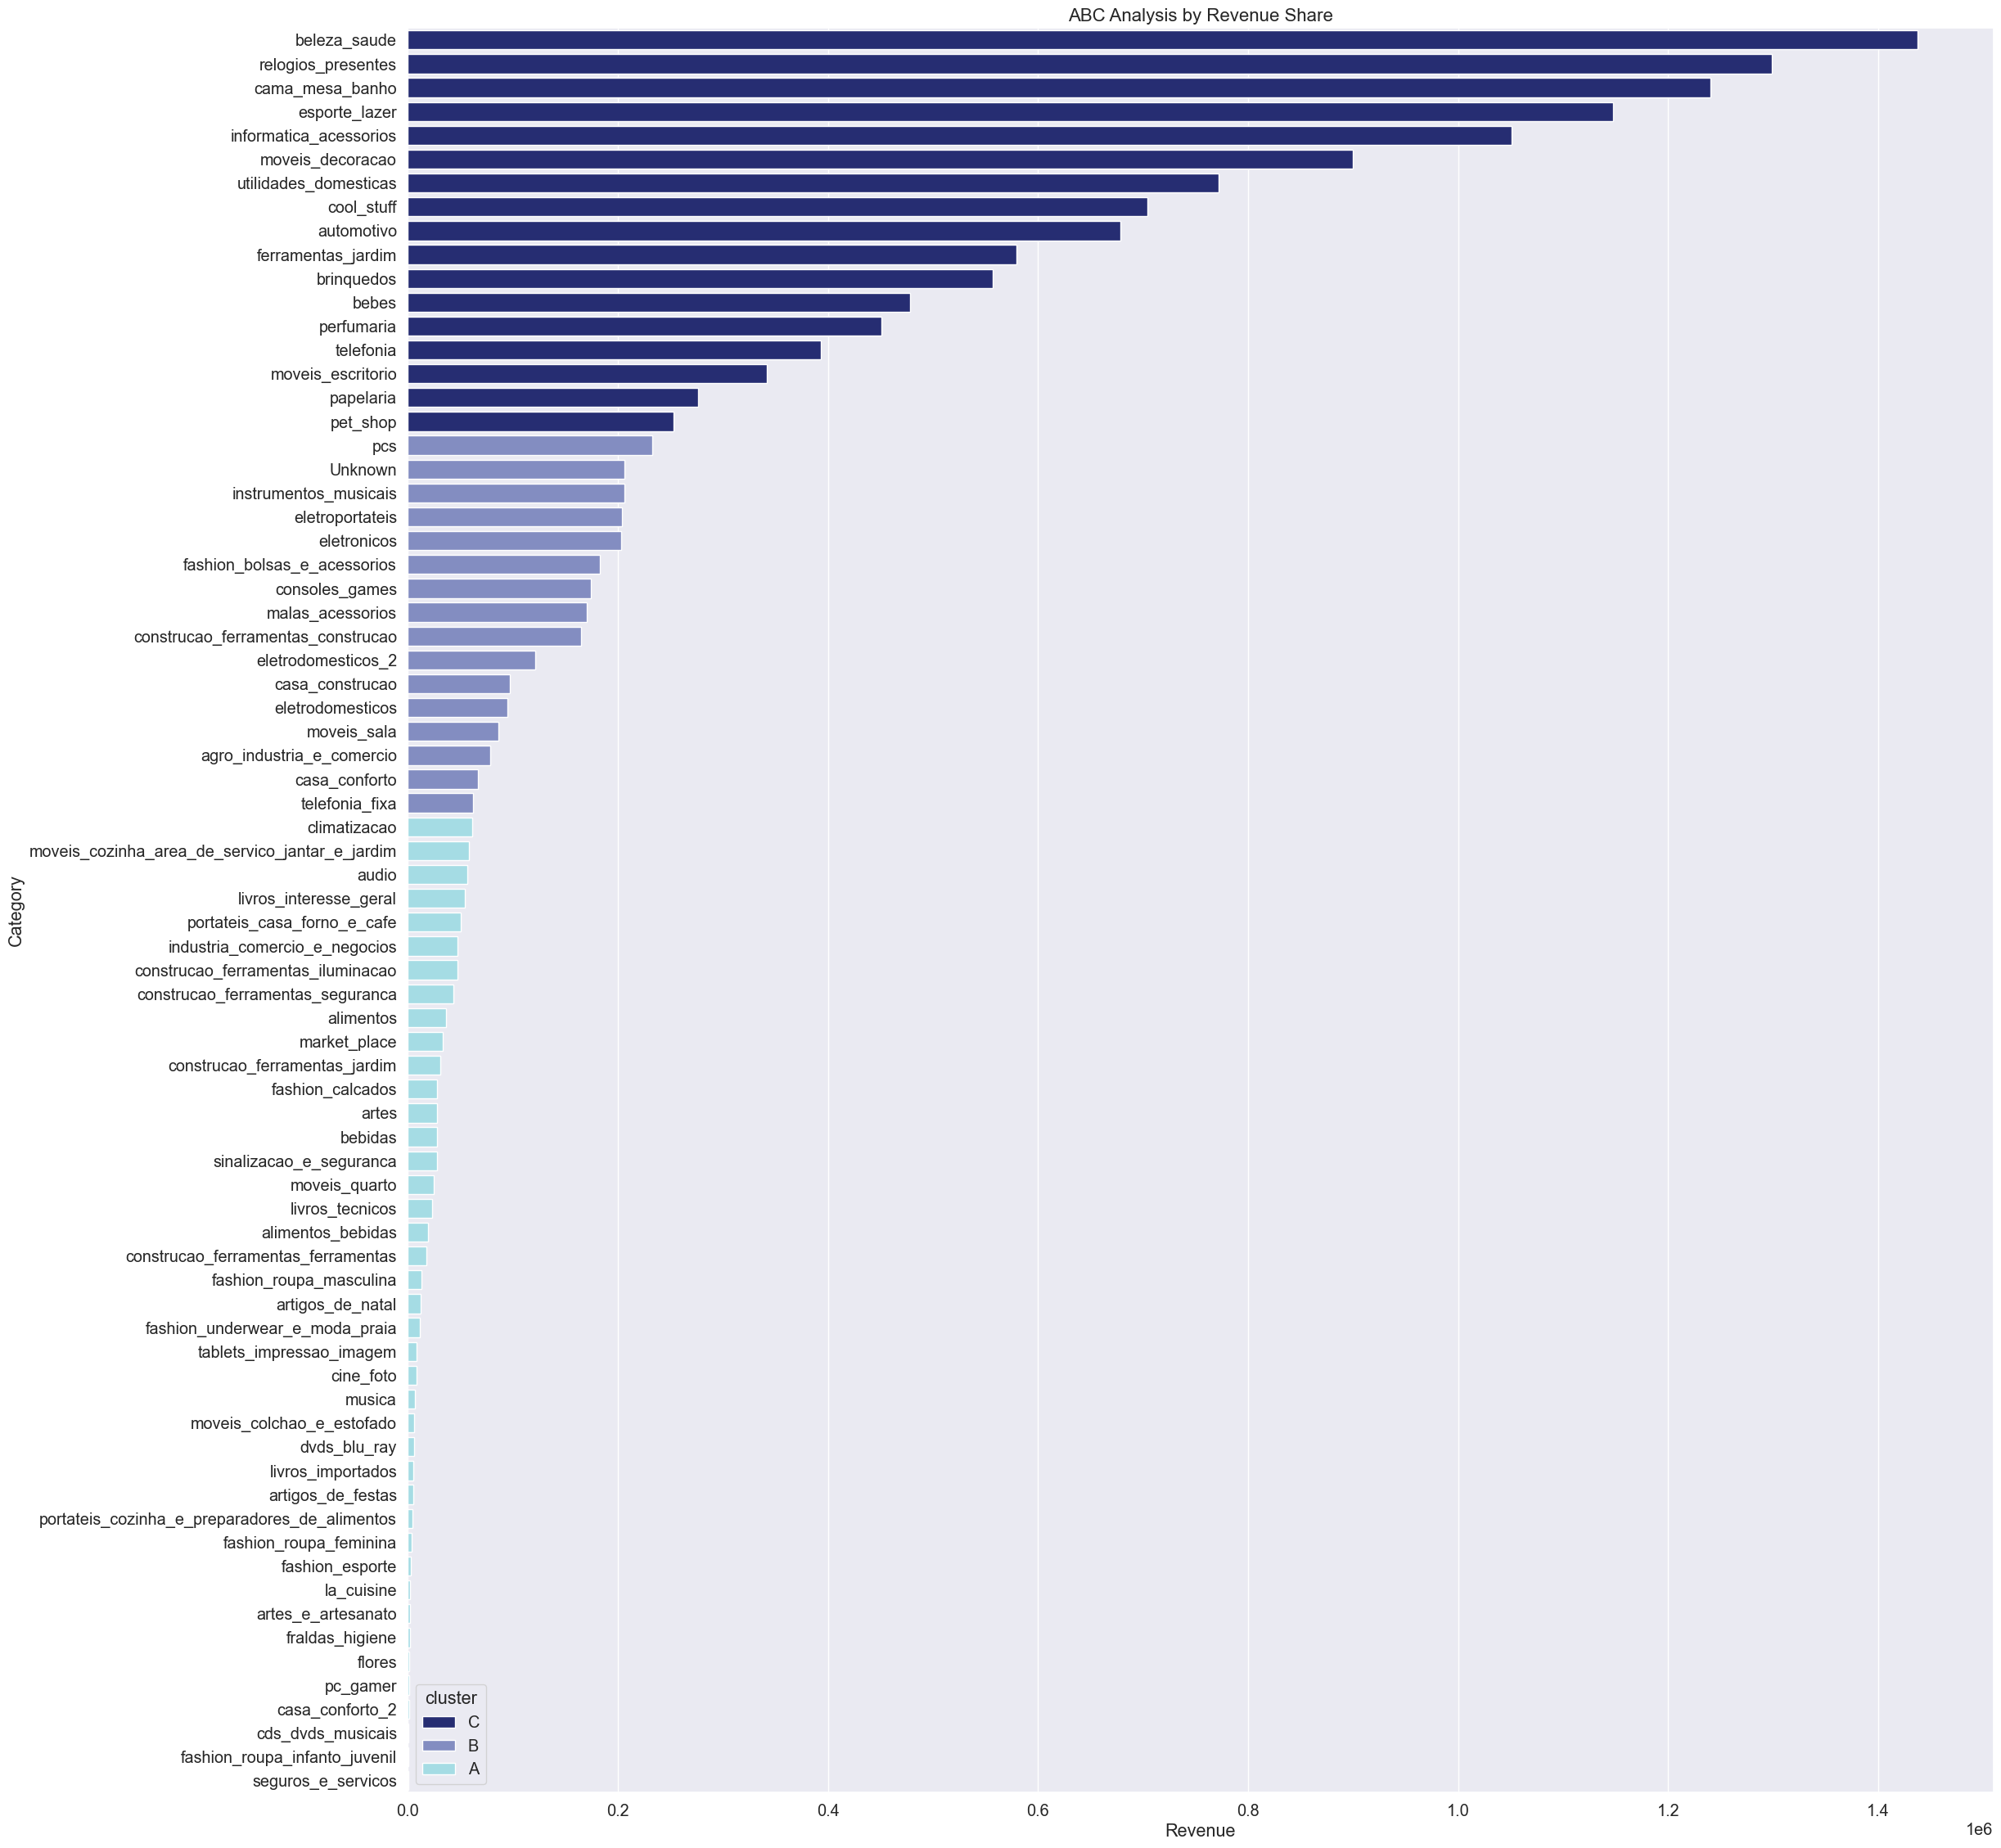

In [82]:
plt.figure(figsize=(25,28))

sns.barplot(
    data=df_abc,
    y='category',
    x='revenue',
    hue='cluster',
    dodge=False,
    palette={
        'A': '#9BE4EE',
        'B': '#7986CB',
        'C': '#1A237E'
    }
)

plt.title('ABC Analysis by Revenue Share', fontsize=16)

plt.xlabel('Revenue')
plt.ylabel('Category')

plt.show()

insight

In [55]:
corr_df = df_category_growth_over_time.select_dtypes(include=['int64', 'float64'])
corr_matrix = corr_df.corr()

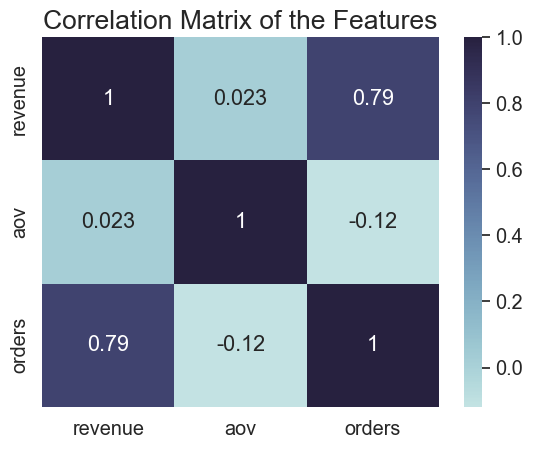

In [56]:
# plt.figure(figsize=(4,3))
sns.set(font_scale=1.3)
cmap = sns.color_palette("ch:start=.2,rot=-.3", as_cmap=True)
sns.heatmap(corr_matrix, cmap=cmap,annot=True)
plt.title("Correlation Matrix of the Features",fontsize=19)
plt.show()

<Axes: xlabel='aov', ylabel='revenue'>

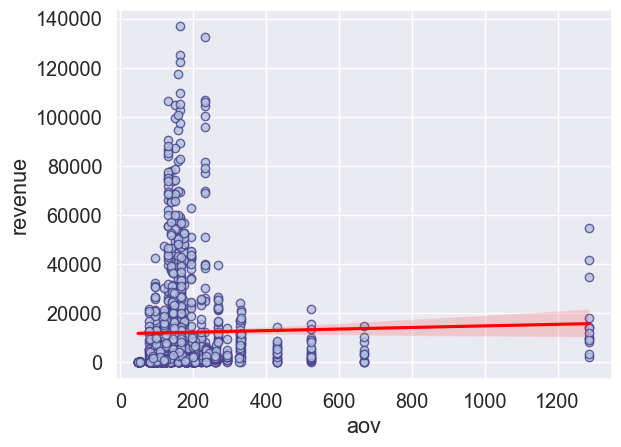

In [57]:
sns.regplot(data=df_category_growth_over_time, x="aov", y="revenue", 
            scatter_kws={'color': 'lightsteelblue', 'edgecolor': 'darkslateblue'},
            line_kws={'color': 'red'})

<Axes: xlabel='orders', ylabel='revenue'>

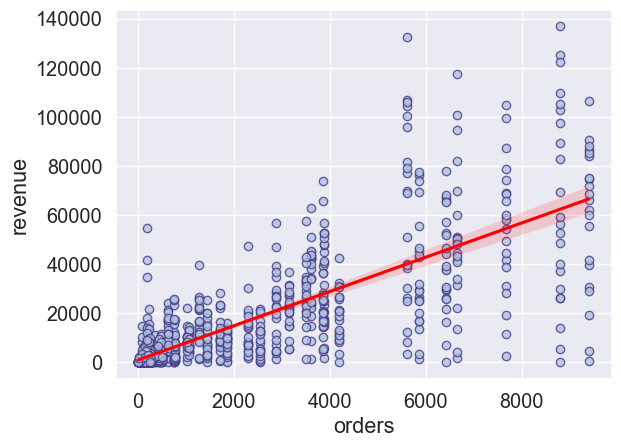

In [58]:
sns.regplot(data=df_category_growth_over_time, x="orders", y="revenue", 
            scatter_kws={'color': 'lightsteelblue', 'edgecolor': 'darkslateblue'},
            line_kws={'color': 'red'})

insight

## Cohort analysis

In [59]:

df_cohort = df_final_dataset.copy()

df_cohort['order_purchase_timestamp'] = pd.to_datetime(
    df_cohort['order_purchase_timestamp']
)

df_cohort = df_cohort[[
    'customer_unique_id',
    'order_id',
    'order_purchase_timestamp'
]]

df_cohort = df_cohort.drop_duplicates()

df_cohort['order_month'] = (
    df_cohort['order_purchase_timestamp']
    .dt.to_period('M')
)

df_cohort['cohort_month'] = (
    df_cohort
    .groupby('customer_unique_id')['order_month']
    .transform('min')
)
def get_month_index(df, order_col, cohort_col):

    order_year = df[order_col].dt.year
    order_month = df[order_col].dt.month

    cohort_year = df[cohort_col].dt.year
    cohort_month = df[cohort_col].dt.month

    return (
        (order_year - cohort_year) * 12
        + (order_month - cohort_month)
    )
df_cohort['cohort_index'] = get_month_index(
    df_cohort,
    'order_month',
    'cohort_month'
)
cohort_data = (
    df_cohort
    .groupby(['cohort_month', 'cohort_index'])
    ['customer_unique_id']
    .nunique()
    .reset_index()
)
cohort_table = cohort_data.pivot(
    index='cohort_month',
    columns='cohort_index',
    values='customer_unique_id'
)
cohort_size = cohort_table.iloc[:, 0]

retention_matrix = cohort_table.divide(
    cohort_size,
    axis=0
)

retention_matrix = retention_matrix.round(3) * 100
retention_matrix.head()

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-10,100.0,NaN,NaN,NaN,NaN,NaN,0.4,NaN,NaN,0.4,NaN,0.4,NaN,0.4,NaN,0.4,NaN,0.4,0.8,0.8
2016-12,100.0,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,100.0,0.3,0.3,0.1,0.4,0.1,0.4,0.1,0.1,NaN,0.4,0.1,0.7,0.4,0.1,0.1,0.3,0.4,0.1,NaN
2017-02,100.0,0.2,0.3,0.1,0.4,0.1,0.2,0.2,0.1,0.2,0.1,0.3,0.1,0.2,0.1,0.1,0.1,0.2,NaN,NaN
2017-03,100.0,0.4,0.4,0.4,0.4,0.2,0.2,0.3,0.3,0.1,0.4,0.1,0.2,0.1,0.2,0.2,0.1,0.1,NaN,NaN


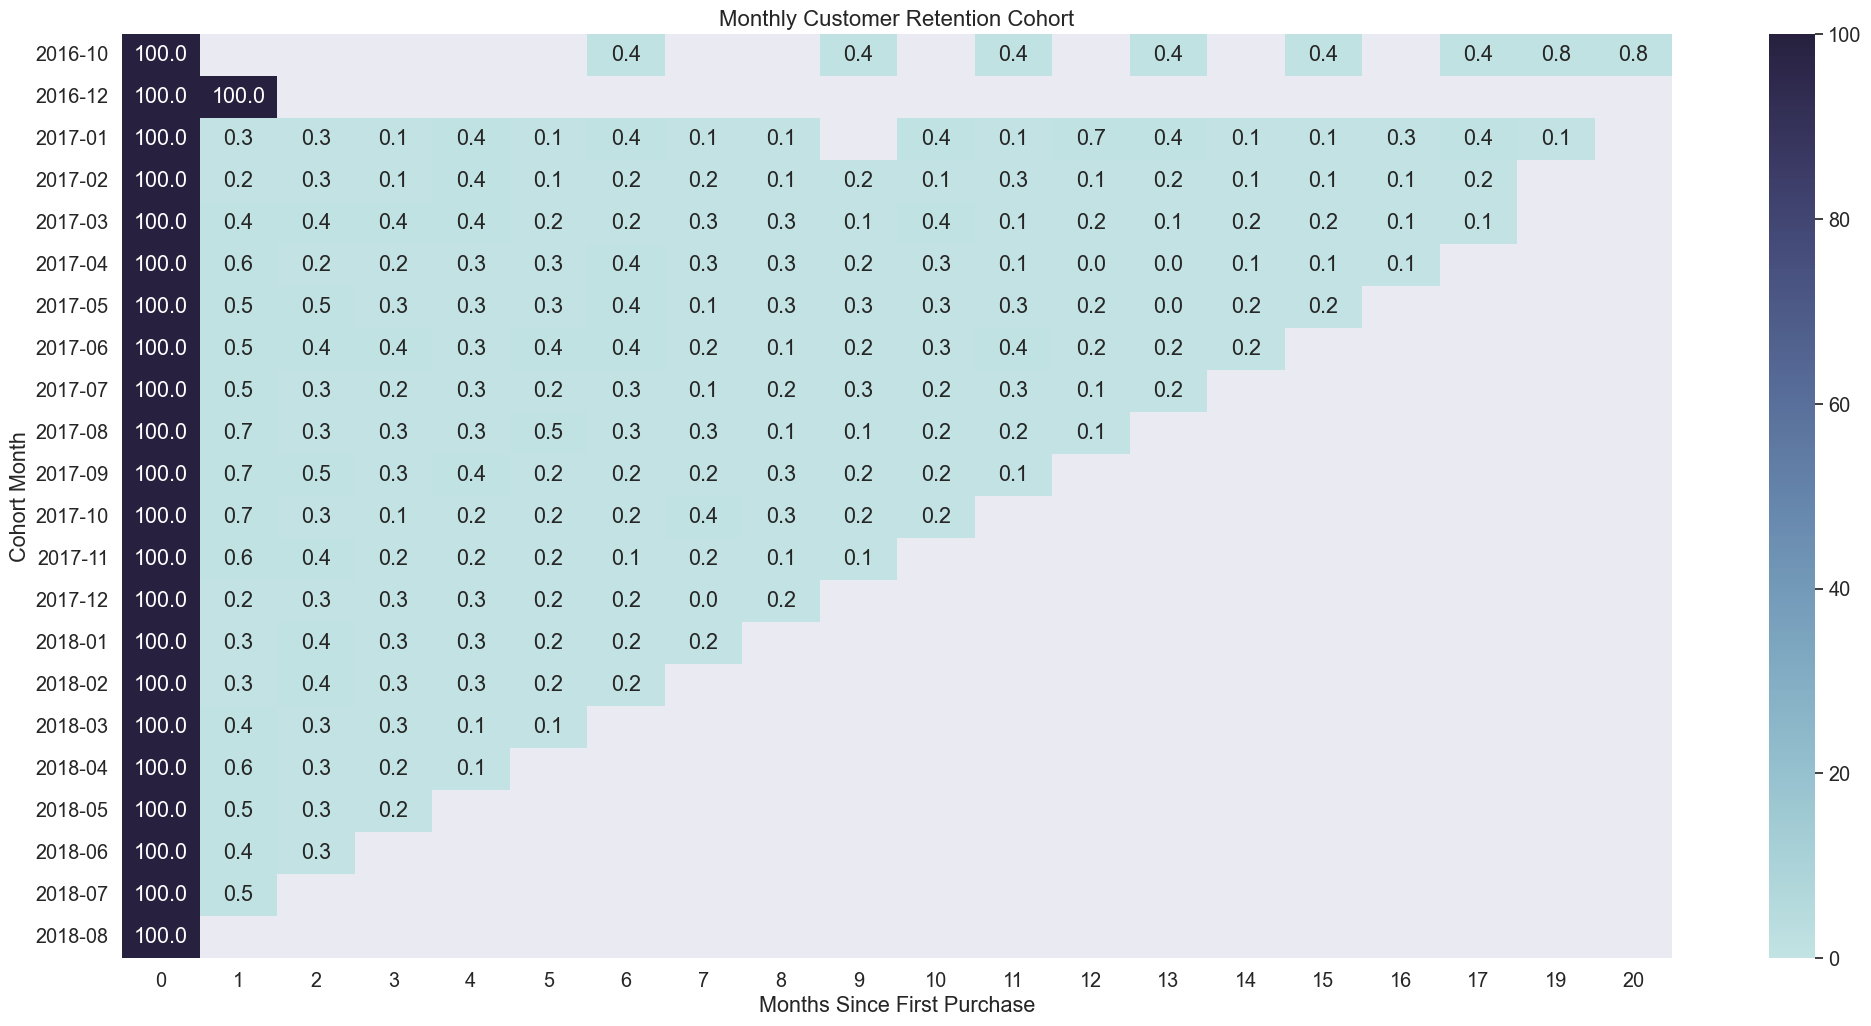

In [60]:
plt.figure(figsize=(25,12))
cmap = sns.color_palette("ch:start=.2,rot=-.3", as_cmap=True)
sns.heatmap(
    retention_matrix,
    annot=True,
    fmt='.1f',
    cmap=cmap
).grid(False)
plt.title('Monthly Customer Retention Cohort', fontsize=16)
plt.ylabel('Cohort Month')
plt.xlabel('Months Since First Purchase')
plt.show()

Insight

## AOV with revenue by state

In [61]:
df_revenue_per_state.head()

,seller_state,total_orders,total_revenue,avg_order_value,revenue_percent
0,SP,69854,10163091.37,145.49,64.59
1,PR,7647,1453098.55,190.02,9.23
2,MG,7880,1213270.24,153.97,7.71
3,RJ,4330,930917.92,214.99,5.92
4,SC,3649,729704.76,199.97,4.64


In [62]:
df_revenue_per_state.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   seller_state     23 non-null     object 
 1   total_orders     23 non-null     int64  
 2   total_revenue    23 non-null     float64
 3   avg_order_value  23 non-null     float64
 4   revenue_percent  23 non-null     float64
dtypes: float64(3), int64(1), object(1)
memory usage: 1.0+ KB


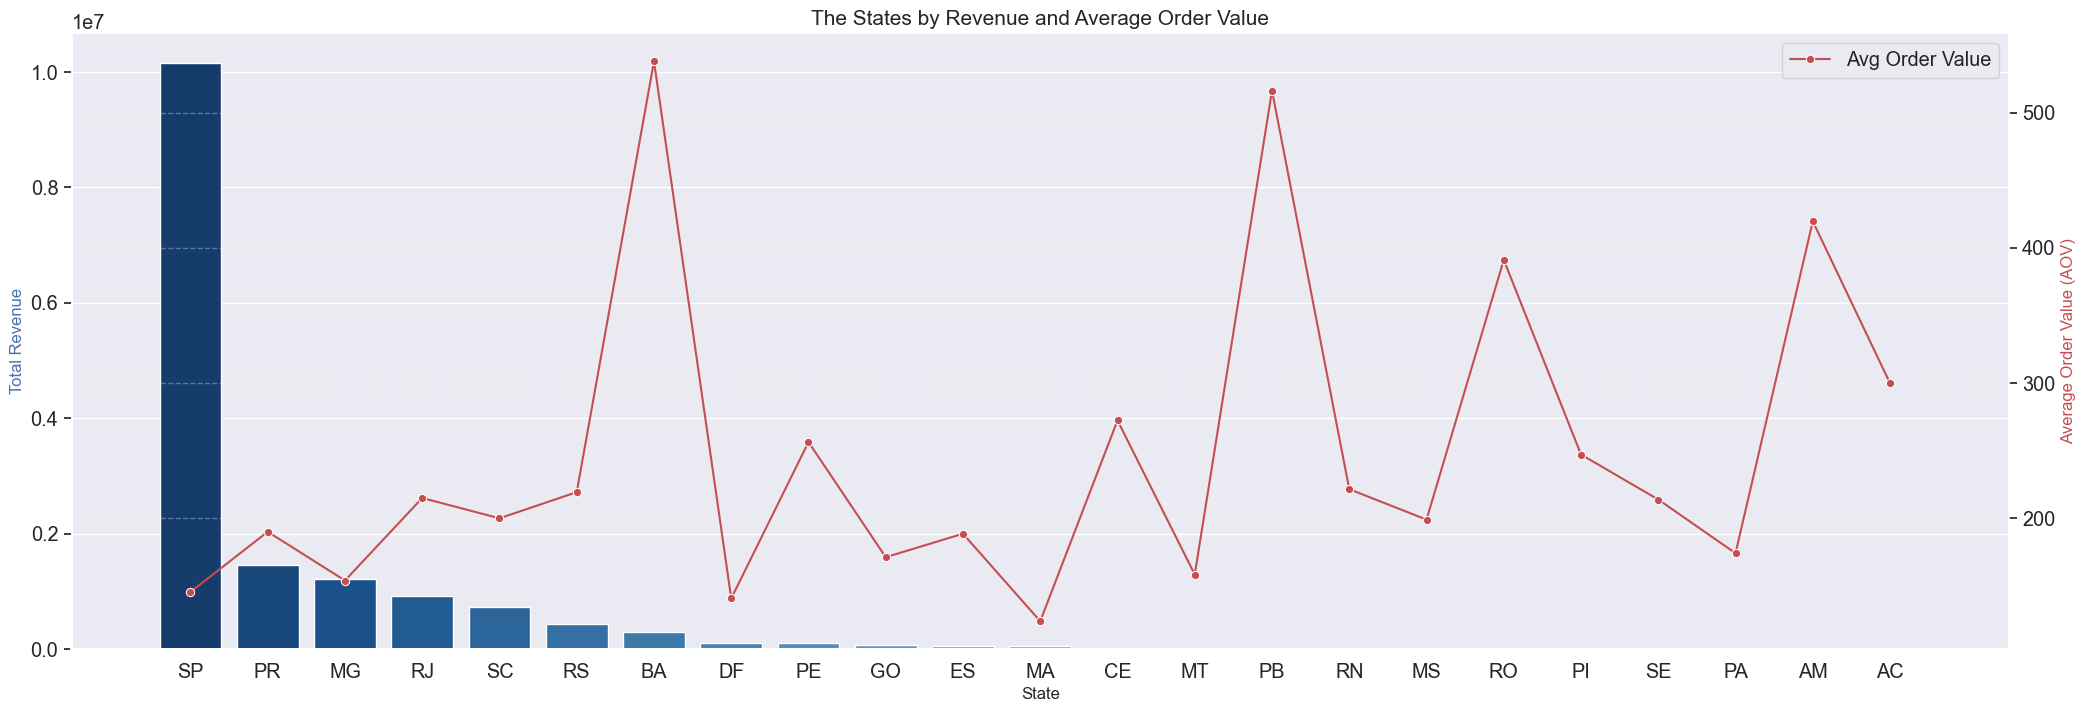

In [63]:
# Visualizing

fig, ax1 = plt.subplots(figsize=(25, 8))

# Bar chart for revenue
sns.barplot(
    data=df_revenue_per_state, 
    x='seller_state', 
    y='total_revenue', 
    ax=ax1, 
    palette='Blues_r', 
    hue='seller_state', 
    legend=False
)
ax1.set_ylabel('Total Revenue', color='b', fontsize=12)
ax1.set_xlabel('State', fontsize=12)

# Line graph for average check
ax2 = ax1.twinx() 

sns.lineplot(
    data=df_revenue_per_state, 
    x='seller_state', 
    y='avg_order_value', 
    marker='o', 
    color='r', 
    ax=ax2,
    label='Avg Order Value'
)
ax2.set_ylabel('Average Order Value (AOV)', color='r', fontsize=12)

plt.title('The States by Revenue and Average Order Value', fontsize=15)
plt.grid(True, axis='y', linestyle='--', alpha=0.3)
plt.show()

Insight

## Geolocation analysis

In [64]:
df_geolocation_analysis = df_final_dataset[['order_id', 'order_status', 'order_purchase_timestamp',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_id', 'customer_unique_id', 'customer_city', 'customer_state',
       'customer_zip_code_prefix', 'geolocation_lat', 'geolocation_lng','avg_review_score', 'revenue',
       'delivery_days', 'late_delivery_flag']]
df_geolocation_analysis.head()

,order_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,customer_id,customer_unique_id,customer_city,customer_state,customer_zip_code_prefix,geolocation_lat,geolocation_lng,avg_review_score,revenue,delivery_days,late_delivery_flag
0,001d8f0e34a38c37f7dba2a37d4eba8b,delivered,2017-05-14 17:19:44+07:00,2017-05-26 13:14:50+07:00,2017-05-24 00:00:00+07:00,d987da9fb4086ab7c2c0f83963cd6722,870a0bdc769f9a7870309036740e79ea,sao paulo,SP,2929,-23.492688,-46.706338,1.0,26.77,11.0,1
1,00018f77f2f0320c557190d7a144bdd3,delivered,2017-04-26 10:53:06+07:00,2017-05-12 16:04:24+07:00,2017-05-15 00:00:00+07:00,f6dd3ec061db4e3987629fe6b26e5cce,eb28e67c4c0b83846050ddfb8a35d051,santa fe do sul,SP,15775,-20.220527,-50.903424,4.0,259.83,16.0,0
2,000229ec398224ef6ca0657da4fc703e,delivered,2018-01-14 14:33:31+07:00,2018-01-22 13:19:16+07:00,2018-02-05 00:00:00+07:00,6489ae5e4333f3693df5ad4372dab6d3,3818d81c6709e39d06b2738a8d3a2474,para de minas,MG,35661,-19.870305,-44.593326,5.0,216.87,7.0,0
3,00048cc3ae777c65dbb7d2a0634bc1ea,delivered,2017-05-15 21:42:34+07:00,2017-05-22 13:44:35+07:00,2017-06-06 00:00:00+07:00,816cbea969fe5b689b39cfc97a506742,85c835d128beae5b4ce8602c491bf385,uberaba,MG,38017,-19.740199,-47.924793,4.0,34.59,6.0,0
4,0005a1a1728c9d785b8e2b08b904576c,delivered,2018-03-19 18:40:33+07:00,2018-03-29 18:17:31+07:00,2018-03-29 00:00:00+07:00,16150771dfd4776261284213b89c304e,639d23421f5517f69d0c3d6e6564cf0e,santos,SP,11075,-23.954600,-46.337731,1.0,157.60,9.0,1


In [65]:
df_geolocation_analysis['delivery_delay_days'] = (
    df_geolocation_analysis['order_delivered_customer_date']
    -
    df_geolocation_analysis['order_estimated_delivery_date']
).dt.days

In [66]:
df_geolocation_analysis.head()

,order_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,customer_id,customer_unique_id,customer_city,customer_state,customer_zip_code_prefix,geolocation_lat,geolocation_lng,avg_review_score,revenue,delivery_days,late_delivery_flag,delivery_delay_days
0,001d8f0e34a38c37f7dba2a37d4eba8b,delivered,2017-05-14 17:19:44+07:00,2017-05-26 13:14:50+07:00,2017-05-24 00:00:00+07:00,d987da9fb4086ab7c2c0f83963cd6722,870a0bdc769f9a7870309036740e79ea,sao paulo,SP,2929,-23.492688,-46.706338,1.0,26.77,11.0,1,2
1,00018f77f2f0320c557190d7a144bdd3,delivered,2017-04-26 10:53:06+07:00,2017-05-12 16:04:24+07:00,2017-05-15 00:00:00+07:00,f6dd3ec061db4e3987629fe6b26e5cce,eb28e67c4c0b83846050ddfb8a35d051,santa fe do sul,SP,15775,-20.220527,-50.903424,4.0,259.83,16.0,0,-3
2,000229ec398224ef6ca0657da4fc703e,delivered,2018-01-14 14:33:31+07:00,2018-01-22 13:19:16+07:00,2018-02-05 00:00:00+07:00,6489ae5e4333f3693df5ad4372dab6d3,3818d81c6709e39d06b2738a8d3a2474,para de minas,MG,35661,-19.870305,-44.593326,5.0,216.87,7.0,0,-14
3,00048cc3ae777c65dbb7d2a0634bc1ea,delivered,2017-05-15 21:42:34+07:00,2017-05-22 13:44:35+07:00,2017-06-06 00:00:00+07:00,816cbea969fe5b689b39cfc97a506742,85c835d128beae5b4ce8602c491bf385,uberaba,MG,38017,-19.740199,-47.924793,4.0,34.59,6.0,0,-15
4,0005a1a1728c9d785b8e2b08b904576c,delivered,2018-03-19 18:40:33+07:00,2018-03-29 18:17:31+07:00,2018-03-29 00:00:00+07:00,16150771dfd4776261284213b89c304e,639d23421f5517f69d0c3d6e6564cf0e,santos,SP,11075,-23.954600,-46.337731,1.0,157.60,9.0,1,0


In [67]:
# Late delivery flag
# 1 = delayed
# 0 = on time

df_geolocation_analysis['late_delivery_flag'] = (
    df_geolocation_analysis['delivery_delay_days'] > 0
).astype(int)

In [68]:
# %pip install plotly

In [69]:
# pip install ipywidgets

In [70]:
# import plotly.graph_objects as go
# import plotly.express as px
# import plotly.io as pio

# pio.renderers.default = "notebook"
# # =========================================================
# # AGGREGATE GEOLOCATION DATA
# # =========================================================

# df_state_delay = (
#     df_geolocation_analysis
#     .groupby('customer_state')
#     .agg({
#         'late_delivery_flag': 'mean',
#         'delivery_delay_days': 'mean',
#         'order_id': 'count',
#         'revenue': 'sum',
#         'geolocation_lat': 'mean',
#         'geolocation_lng': 'mean'
#     })
#     .reset_index()
# )
# # =========================================================
# # RENAME COLUMNS
# # =========================================================

# df_state_delay.columns = [
#     'state',
#     'delay_rate',
#     'avg_delay_days',
#     'total_orders',
#     'total_revenue',
#     'lat',
#     'lng'
# ]

# # =========================================================
# # CONVERT TO PERCENTAGE
# # =========================================================

# df_state_delay['delay_rate_percent'] = (
#     df_state_delay['delay_rate'] * 100
# ).round(2)

# # =========================================================
# # CREATE HOVER TEXT
# # =========================================================

# df_state_delay['text'] = (
#     'State: ' + df_state_delay['state']
#     + '<br>Delay Rate: ' + df_state_delay['delay_rate_percent'].astype(str) + '%'
#     + '<br>Avg Delay Days: ' + df_state_delay['avg_delay_days'].round(2).astype(str)
#     + '<br>Total Orders: ' + df_state_delay['total_orders'].astype(str)
#     + '<br>Total Revenue: $' + df_state_delay['total_revenue'].round(2).astype(str)
# )

# # =========================================================
# # CREATE MAP FIGURE
# # =========================================================

# fig = go.Figure()

# # =========================================================
# # ADD GEO SCATTER
# # =========================================================

# fig = px.scatter_geo(
#     df_state_delay,
#     lat='lat',
#     lon='lng',
#     size='total_orders',
#     color='delay_rate_percent',
#     hover_name='state',
#     hover_data={
#         'delay_rate_percent': True,
#         'avg_delay_days': True,
#         'total_orders': True,
#         'total_revenue': True,
#         'lat': False,
#         'lng': False
#     },
#     color_continuous_scale='Reds',
#     title='Delivery Delay Rate by State'
# )

# # =========================================================
# # UPDATE LAYOUT
# # =========================================================

# fig.update_layout(
#     title='Delivery Delay Rate by Brazilian State',
#     geo=dict(
#         scope='south america',
#         fitbounds='locations',
#         projection_scale=3,
#         showland=True,
#         landcolor='rgb(240,240,240)',
#         showcountries=True,
#         countrycolor='gray'
#     ),
#     height=700,
#     width=1000
# )
# fig.show()

In [71]:
# df_geolocation_analysis['estimated_delivery_days'] = (df_geolocation_analysis['order_estimated_delivery_date'] - df_geolocation_analysis['order_purchase_timestamp']).dt.days

In [72]:
# df_delivery_compare = pd.DataFrame({
#     'delivery_type': ['Actual Delivery', 'Estimated Delivery'],
#     'days': [
#         df_geolocation_analysis['actual_delivery_days'].mean(),
#         df_geolocation_analysis['estimated_delivery_days'].mean()
#     ]
# })

In [73]:
# plt.figure(figsize=(6, 8))
# ax = sns.barplot(data = df_delivery_compare,
#                  x='delivery_type',
#                  y='days',
#                  color='midnightblue'
# )
# # add value labels
# for p in ax.patches:
#     ax.annotate(f'{p.get_height():.2f}',
#                (
#                    p.get_x() + p.get_width()/2,
#                    p.get_height()
#                ),
#                 ha='center',
#                 va='bottom'
#             )
# plt.title('Actual vs Estimated Delivery Time')
# plt.ylabel('Average Delivery Days')
# plt.xlabel('')
# plt.show()

In [74]:
df_geolocation_analysis['delivery_status'] = np.where(
    df_geolocation_analysis['delivery_delay_days'] > 0,
    'Delayed',
    np.where(
        df_geolocation_analysis['delivery_delay_days'] < 0,
        'Early',
        'One Time'
    )
)

In [75]:
df_delivery_status = (
    df_geolocation_analysis.groupby('delivery_status').agg({'order_id': 'count'}).reset_index()
)

In [76]:
df_delivery_status['percentage'] = (
    df_delivery_status['order_id']/df_delivery_status['order_id'].sum()*100
).round(2)

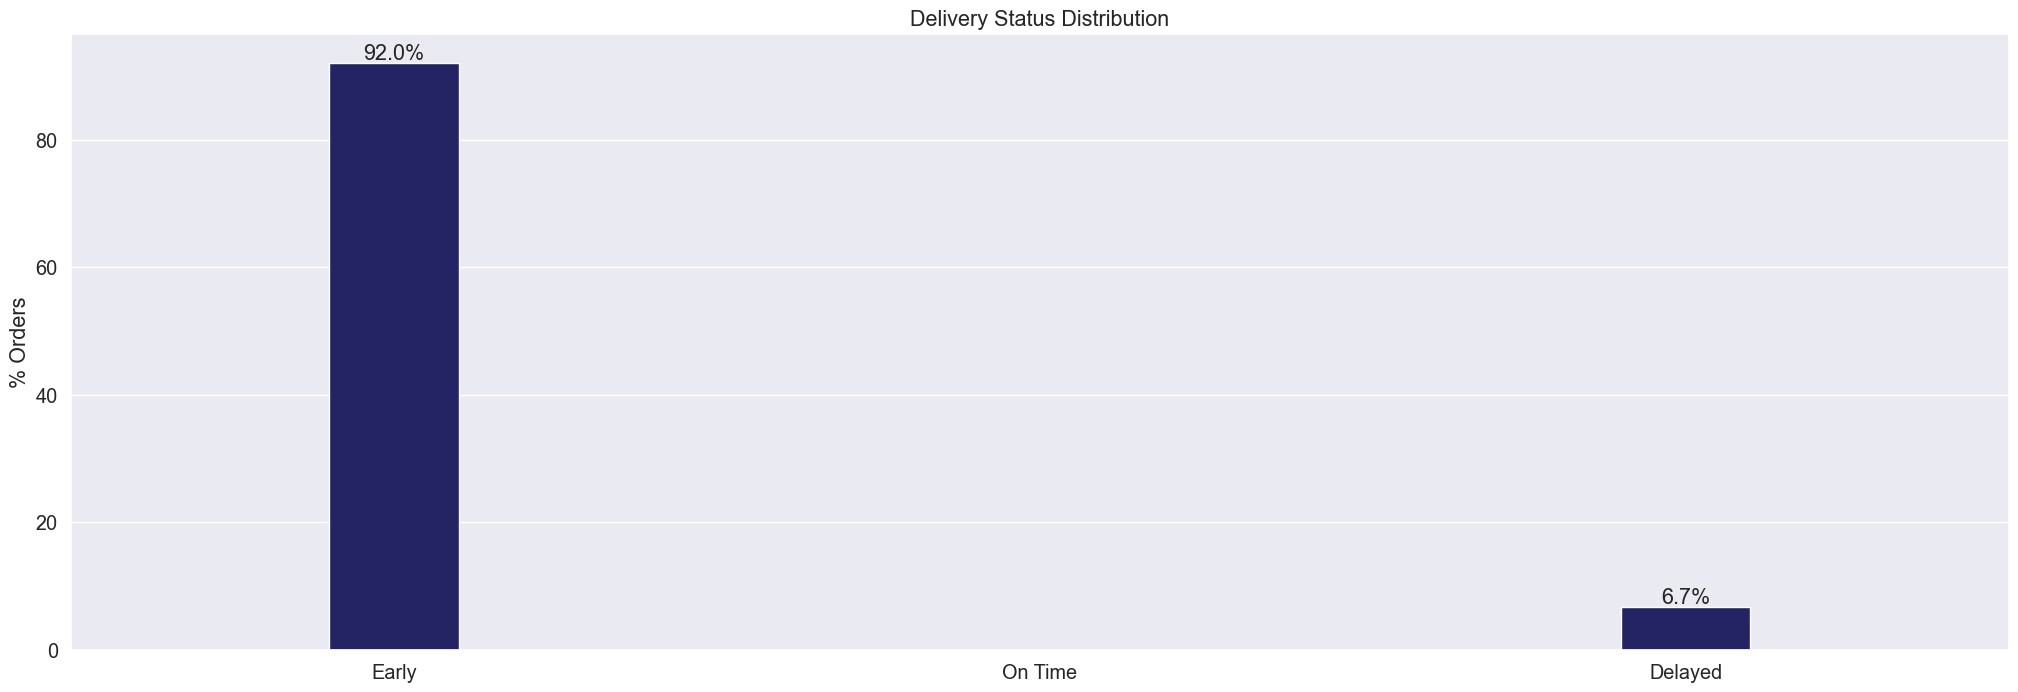

In [77]:
df_delivery_status['percentage'] = (
    df_delivery_status['order_id']
    / df_delivery_status['order_id'].sum()
    * 100
)

plt.figure(figsize=(25,8))

ax = sns.barplot(
    data=df_delivery_status,
    x='delivery_status',
    y='percentage',
    order=['Early','On Time','Delayed'],
    width=0.2,
    color='midnightblue'
)

ax.bar_label(
    ax.containers[0],
    fmt='%.1f%%'
)

plt.title('Delivery Status Distribution')
plt.ylabel('% Orders')
plt.xlabel('')

plt.show()

## NLP review

In [10]:
# pip install deep-translator

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from deep_translator import GoogleTranslator

from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# NLTK tools for text processing
import re, nltk
from nltk import word_tokenize
from nltk.corpus import stopwords
from wordcloud import WordCloud, STOPWORDS

In [3]:
translate_text = GoogleTranslator(source='pt', target='en').translate('Recebi bem antes do prazo estipulado.')
print(translate_text)

I received it well before the stipulated deadline.


In [13]:
df_olist_order_reviews_dataset = pd.read_csv("./data-analysis/olist_order_reviews_dataset.csv")
df_olist_order_reviews_dataset.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [5]:
df_olist_order_reviews_dataset.info()
df_olist_order_reviews_dataset.shape
df_olist_order_reviews_dataset.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [6]:
# Seperating the review and the title
review_data_title = df_olist_order_reviews_dataset['review_comment_title']
review_data = df_olist_order_reviews_dataset['review_comment_message']
# Dropping NaN values
review_data_title = review_data_title.dropna()
review_data = review_data.dropna()
# Resetting the reviews index
review_data_title = review_data_title.reset_index(drop=True)
review_data = review_data.reset_index(drop=True)

print(review_data_title.shape)
print(review_data.shape)

(11568,)
(40977,)


In [14]:
# Transforming the reviews data by removing stopwords, using regular expressions module to accept only letters
# Tokenizing those words and then making all the words lower case for consistency.
comments = []
stop_words = set(stopwords.words('portuguese'))

for words in review_data:
    only_letters = re.sub("[^a-zA-Z]", " ", words)
    tokens = nltk.word_tokenize(only_letters)
    lower_case = [l.lower() for l in tokens]
    filtered_result = list(filter(lambda l: l not in stop_words, lower_case))
    comments.append(' '.join(filtered_result))

print(comments)

['recebi bem antes prazo estipulado', 'parab ns lojas lannister adorei comprar internet seguro pr tico parab ns todos feliz p scoa', 'aparelho eficiente site marca aparelho impresso desinfector chegar outro nome atualizar marca correta vez aparelho', 'pouco travando valor ta boa', 'vendedor confi vel produto ok entrega antes prazo', 'gostaria saber sempre recebi compra agora decpcionou', 'p ssimo', 'loja nota', 'obrigado aten amim dispensada', 'compra realizada facilmente entrega efetuada antes prazo dado produto j come usado at presente problemas', 'rel gio bonito barato', 'n gostei comprei gato lebre', 'sempre compro internet entrega ocorre antes prazo combinado acredito prazo m ximo stark prazo m ximo j esgotou ainda n recebi produto', 'recebi exatamente esperava demais encomendas outros vendedores atrasaram chegou prazo', 'recomendo', 'boa', 't completamente apaixonada loja super respons vel confi vel', 'nada chegar pedido', 'bom cheiroso', 'otimo vendedor chegou ate antes prazo ad

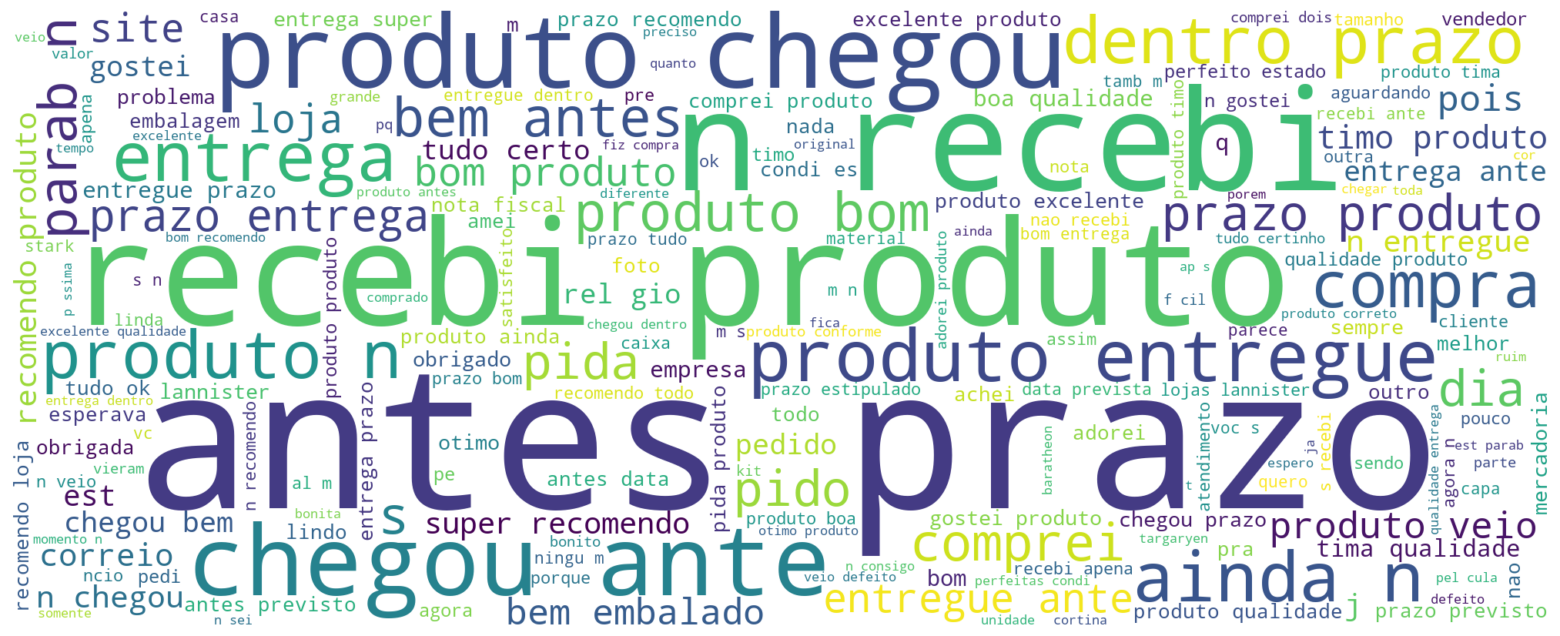

In [15]:
unique_string=(" ").join(comments)
wordcloud = WordCloud(width = 2000, height = 800, background_color = 'white').generate(unique_string)
plt.figure(figsize=(25, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [20]:
# Using CountVectorizer to get the most important word
co = CountVectorizer(ngram_range=(3, 3))
counts = co.fit_transform(comments)
important_trigrams = pd.DataFrame(counts.sum(axis=0), columns=co.get_feature_names_out()).T.sort_values(0, ascending=False).head(50)

# Reset index, rename the columns and apply the translate to English
important_trigrams = important_trigrams.reset_index()
important_trigrams.rename(columns={'index': 'trigrams', 0: 'frequency'}, inplace=True)

translator = GoogleTranslator(source='pt', target='en')

important_trigrams['english_translation'] = important_trigrams['trigrams'].apply(
    lambda x: translator.translate(x)
)

important_trigrams

,trigrams,frequency,english_translation
0,chegou antes prazo,1108,arrived before deadline
1,bem antes prazo,706,well before the deadline
2,entregue antes prazo,608,delivered before deadline
3,produto chegou antes,448,product arrived early
4,entrega antes prazo,432,delivery before deadline
5,chegou bem antes,416,arrived well before
6,produto entregue antes,374,product delivered before
7,entrega super pida,297,super fast delivery
8,antes prazo previsto,287,before expected deadline
9,produto tima qualidade,257,great quality product


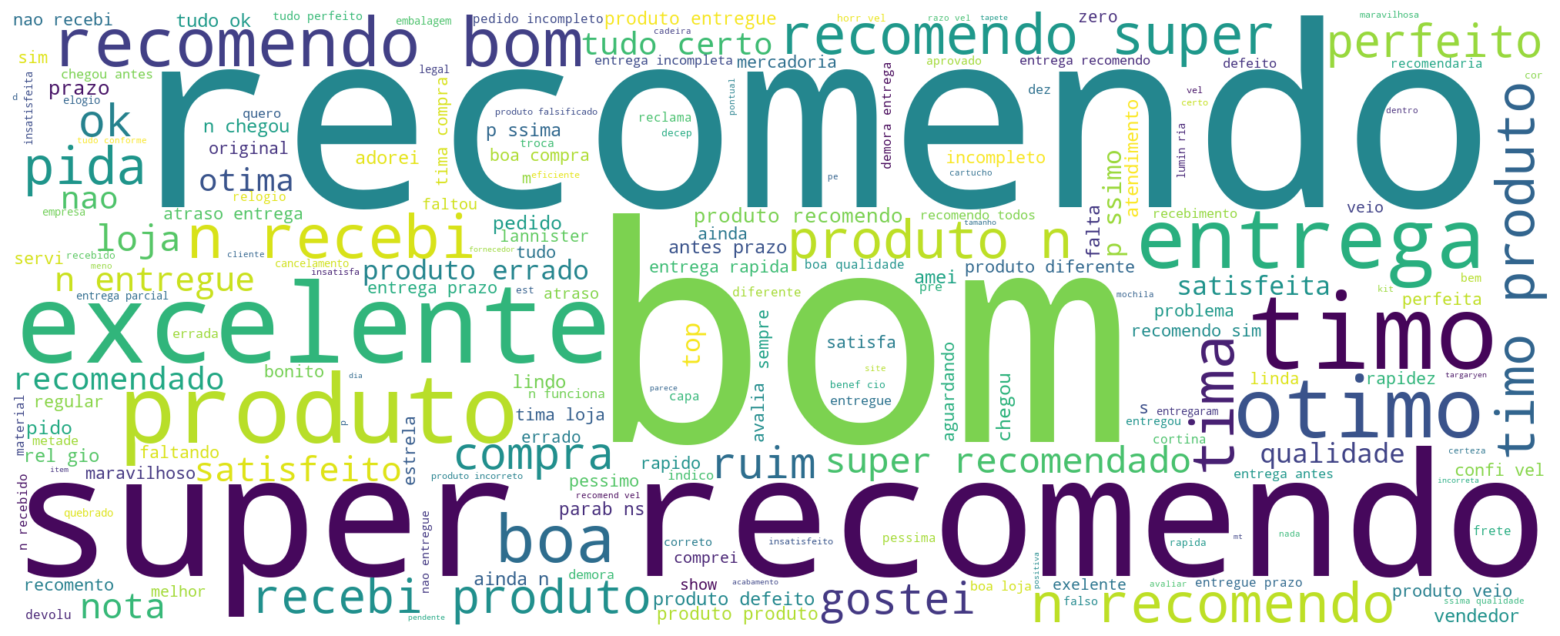

In [24]:
# Processing the reviews titles data
comments_titles = []
stop_words = set(stopwords.words('portuguese'))

for words in review_data_title:
    only_letters = re.sub("[^a-zA-Z]", " ", words)
    tokens = nltk.word_tokenize(only_letters)
    lower_case = [l.lower() for l in tokens]
    filtered_result = list(filter(lambda l: l not in stop_words, lower_case))

    comments_titles.append(' '.join(filtered_result))

# Using wordcloud to visualize the comments titles
unique_string = (" ").join(comments_titles)
wordcloud = WordCloud(width = 2000, height = 800, background_color = 'white').generate(unique_string)

plt.figure(figsize=(25, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [25]:
co = CountVectorizer(ngram_range=(3, 3))
counts = co.fit_transform(comments_titles)
important_trigrams_title = pd.DataFrame(counts.sum(axis=0), columns=co.get_feature_names_out()).T.sort_values(0, ascending=False).head(50)

important_trigrams_title = important_trigrams_title.reset_index()
important_trigrams_title.rename(columns={'index': 'trigrams_title', 0: 'frequency'}, inplace=True)

translator = GoogleTranslator(source='pt', target='en')

important_trigrams_title['english_translation'] = important_trigrams_title['trigrams_title'].apply(
    lambda x: translator.translate(x)
)

important_trigrams_title

,trigrams_title,frequency,english_translation
0,entrega super pida,27,super fast delivery
1,entrega antes prazo,15,delivery before deadline
2,custo benef cio,12,cost benefit
3,nao recebi produto,11,I didn't receive the product
4,chegou antes prazo,11,arrived before deadline
5,produto entregue prazo,8,product delivered on time
6,produto boa qualidade,8,good quality product
7,produto veio defeito,7,product arrived defective
8,produto nao entregue,6,product not delivered
9,entrega super rapida,6,super fast delivery
